In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

# helper functions

In [2]:
def plot_hist(df, column='mape'):

    # 1. Ensure your buckets are in the correct logical order
    category_order = ['tiny', 'small', 'medium', 'large', 'xlarge']
    df['size_bucket'] = pd.Categorical(df['size_bucket'], categories=category_order, ordered=True)

    # 2. Plot
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=column, hue='size_bucket', 
                kde=True, element="step", palette='viridis')

    plt.title('Distribution by Size Bucket')
    plt.show()

In [3]:
def plot_box(df, column='mape', ylim=None):
    # 1. Ensure logical order (Crucial so 'tiny' isn't alphabetical)
    category_order = ['tiny', 'small', 'medium']#, 'large', 'xlarge']
    df['size_bucket'] = pd.Categorical(df['size_bucket'], categories=category_order, ordered=True)

    # 2. Plot
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df, 
        x='size_bucket', 
        y=column, 
        hue='model',  # Adds color by bucket
        # palette='viridis',
        fill=True,          # Ensures the boxes are filled with color
    )
    if ylim:
        plt.ylim(ylim)

    plt.title(f'Distribution of {column} by Size Bucket')
    plt.grid(axis='y', linestyle='--', alpha=0.7) # Helps see values across categories
    plt.show()

In [4]:
def get_stats_table(df, column='mape'):
    # 1. Clean data and ensure order
    df = df.reset_index(drop=True)
    category_order = ['tiny', 'small', 'medium', 'large', 'xlarge']
    df['size_bucket'] = pd.Categorical(df['size_bucket'], categories=category_order, ordered=True)

    # 2. Group by both Bucket and Model, then calculate stats
    stats = df.groupby(['size_bucket', 'model'], observed=False)[column].describe()
    
    # 3. Rename columns for clarity (optional)
    stats = stats.rename(columns={
        '50%': 'median',
        '25%': 'q1',
        '75%': 'q3',
        'count': 'n_samples'
    })

    return stats

In [5]:
def get_overall_stats(df, column='mape'):

    df = df.reset_index(drop=True)
    category_order = ['tiny', 'small', 'medium', 'large', 'xlarge']
    df['size_bucket'] = pd.Categorical(df['size_bucket'], categories=category_order, ordered=True)

    # 2. Group by both Bucket and Model, then calculate stats
    stats = df.groupby(['model'], observed=False)[column].describe()
    
    # 3. Rename columns for clarity (optional)
    stats = stats.rename(columns={
        '50%': 'median',
        '25%': 'q1',
        '75%': 'q3',
        'count': 'n_samples'
    })

    return stats

In [6]:
def format_parquet(df, exponentiate=False):
    if exponentiate:
        df['y_pred'] = np.exp(df['y_pred'].astype(float))
        df['y_true'] = np.exp(df['y_true'].astype(float))

    df['mae'] = (df['y_pred'] - df['y_true']).abs()
    df['mape'] = (df['y_pred'] - df['y_true']) / df['y_true']
    df['mape'] = df['mape'].abs()
    
    return df

# test_v1_train_v2 in-context

In [302]:
# df_ic = pd.read_csv('../../results_temp/cross_county/test_v1_train_v2/results.csv')
df_ic = pd.read_csv('../../results_temp/cross_county/test_v1_train_v2/mape_values_filled_in.csv')

In [303]:
df_ic.head(2)

,model,train_size,test_size,n_features,fit_time,pred_time,r2,mae,rmse,mape,...,n_train_source_external,status,experiment_name,experiment_description,result_type,test_fips,size_bucket,county_test_size,county_train_pool_size,county_train_used
0,tabpfn,10000.0,358081.0,107.0,40.576321,3024.756527,0.613554,98561.074221,187062.592376,42.196051,...,5000.0,success,test_v1_train_v2,"Size-stratified test, mixed training (50% hist...",NaN,NaN,NaN,NaN,NaN,NaN
1,xgboost,10000.0,358081.0,107.0,143.353410,0.509012,0.540514,108309.353289,203975.767275,41.439392,...,5000.0,success,test_v1_train_v2,"Size-stratified test, mixed training (50% hist...",NaN,NaN,NaN,NaN,NaN,NaN


In [304]:
df = pd.concat([df_ic, baseline], ignore_index=True)

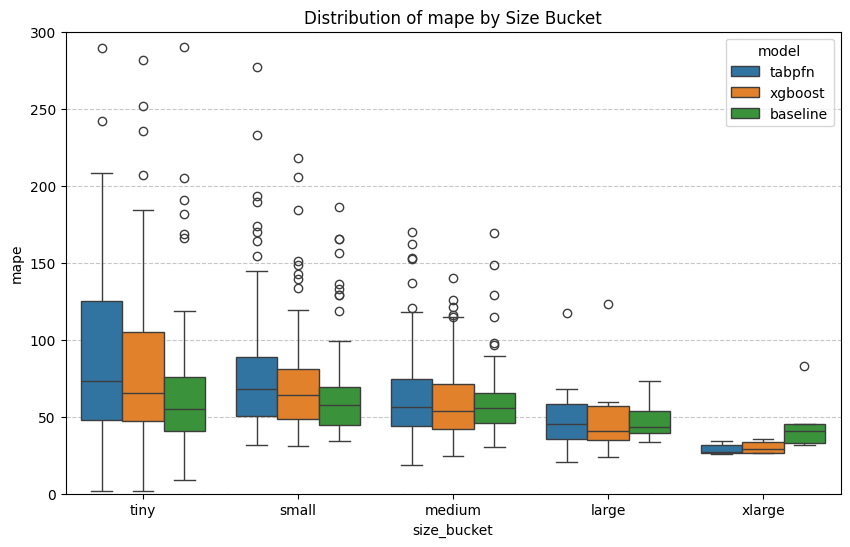

In [306]:
plot_box(df, ylim=(0, 300))

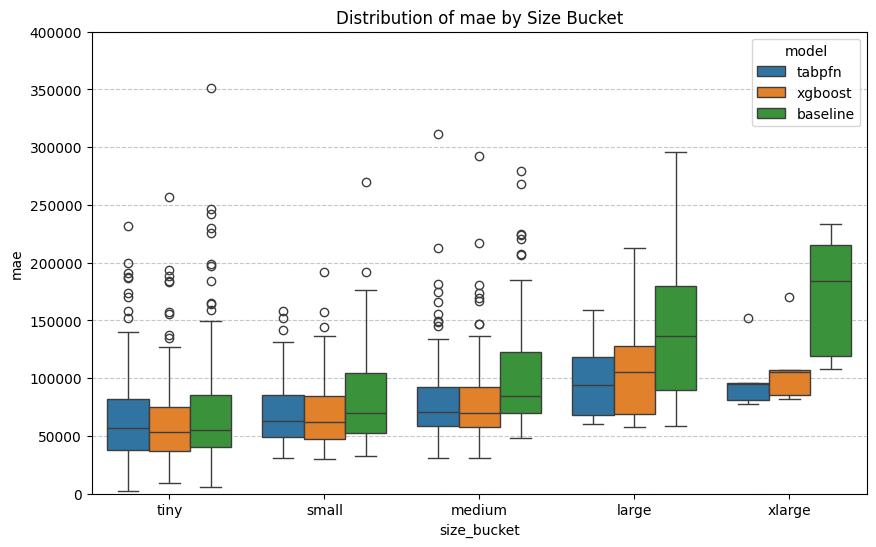

In [307]:
plot_box(df, 'mae', (0, 0.4e6))

In [329]:
test_indices = np.load('../../data/test_v1/test_indices.npy')
train_pool_indices = np.load('../../data/test_v1/train_pool_indices.npy')
train_indices = np.load('../../data/test_v1/train_v2/train_indices.npy')

# Reconstruct the unique_indices array (sorted, deduplicated)
unique_indices = np.unique(np.concatenate([
    test_indices,
    train_pool_indices,
    train_indices
]))

def format_parquet(df):
    df['y_pred'] = np.exp(df['y_pred'].astype(float))
    df['y_true'] = np.exp(df['y_true'].astype(float))

    df['mae'] = (df['y_pred'] - df['y_true']).abs()
    df['mape'] = (df['y_pred'] - df['y_true']) / df['y_true']
    df['mape'] = df['mape'].abs()
    
    return df

xgb = pd.read_parquet('../../results_temp/cross_county/test_v1_train_v2/predictions.parquet')
xgb = xgb.explode(['test_indices', 'y_true', 'y_pred']).reset_index(drop=True)
xgb = format_parquet(xgb)

baseline = pd.read_parquet('../../data/test_v1/baseline_predictions.parquet')
baseline = format_parquet(baseline)

test = pd.concat([xgb, baseline], ignore_index=True)

Text(0.5, 1.0, 'Overall MAPE distribution (10K training points)')

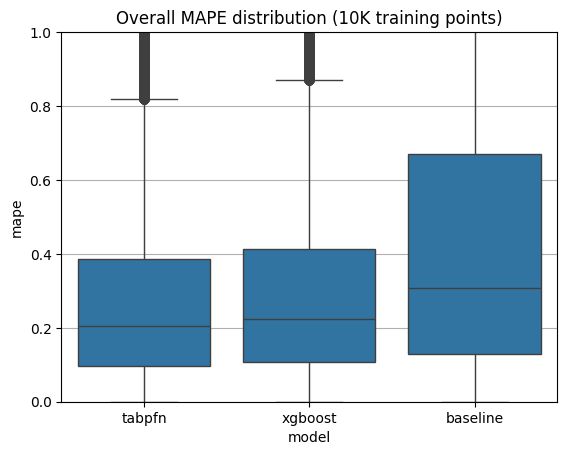

In [332]:
sns.boxplot(
    data=test,
    x='model',
    y='mape',
    fill=True,
)
plt.ylim(0, 1)
plt.grid()
plt.title('Overall MAPE distribution (10K training points)')

Text(0.5, 1.0, 'Overall MAE distribution (10K training points)')

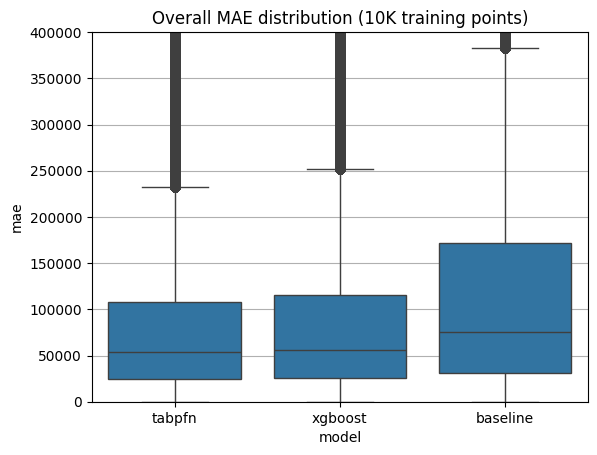

In [333]:
sns.boxplot(
    data=test,
    x='model',
    y='mae',
    fill=True,
)
plt.ylim(0, 0.4e6)
plt.grid()
plt.title('Overall MAE distribution (10K training points)')

# test_v1_train_v5 finetuning

In [89]:
df_ft = pd.read_csv('../../results_temp/finetuning/test_v1_train_v5/mape_values_filled_in.csv')
df = pd.concat([df_ft, baseline], ignore_index=True)

In [70]:
df_ft.head()#[df_ft['county_train_pool_size'] == df_ft['county_train_used']]

,model,train_size,test_size,n_features,fit_time,pred_time,r2,mae,rmse,mape,...,n_train_source_external,status,experiment_name,experiment_description,result_type,test_fips,size_bucket,county_test_size,county_train_pool_size,county_train_used
0,tabpfn,500000.0,358081.0,107.0,4194.596946,536.167424,0.378478,104905.300418,212307.070635,43.531208,...,393148.0,success,tabpfn_finetuning_train_v5,Fine-tune TabPFN with gradient descent on test...,NaN,NaN,NaN,NaN,NaN,NaN
1,xgboost,500000.0,358081.0,107.0,634.062989,0.318268,0.687884,81530.450104,150450.669105,36.871314,...,393148.0,success,tabpfn_finetuning_train_v5,Fine-tune TabPFN with gradient descent on test...,NaN,NaN,NaN,NaN,NaN,NaN
2,tabpfn,NaN,NaN,NaN,NaN,NaN,-0.917095,70953.656250,81860.893079,64.773567,...,NaN,NaN,tabpfn_finetuning_train_v5,Fine-tune TabPFN with gradient descent on test...,per_county,31007.0,tiny,4.0,3.0,3.0
3,xgboost,NaN,NaN,NaN,NaN,NaN,0.760232,19902.294922,28950.111581,11.516101,...,NaN,NaN,tabpfn_finetuning_train_v5,Fine-tune TabPFN with gradient descent on test...,per_county,31007.0,tiny,4.0,3.0,3.0
4,tabpfn,NaN,NaN,NaN,NaN,NaN,0.605548,53471.910784,84914.917330,59.118925,...,NaN,NaN,tabpfn_finetuning_train_v5,Fine-tune TabPFN with gradient descent on test...,per_county,48169.0,tiny,49.0,49.0,49.0


In [96]:
get_stats_table(df)

n_samples       mean         std        min         q1  \
size_bucket model                                                              
tiny        baseline      100.0  85.468310  135.341739   8.545966  40.609751   
            xgboost       100.0  87.449090  103.994347   1.674976  42.627290   
small       baseline      100.0  65.364006   30.307992  34.372657  44.364580   
            xgboost       100.0  60.959821   27.470339  27.065210  43.932534   
medium      baseline      100.0  59.863549   22.927416  30.185458  45.955738   
            xgboost       100.0  51.367990   17.766549  18.836508  37.978133   
large       baseline       10.0  48.058127   12.898675  33.398917  39.044645   
            xgboost        10.0  42.080259   19.271577  15.042124  31.693153   

                         median         q3          max  
size_bucket model                                        
tiny        baseline  55.243657  75.543638  1220.574709  
            xgboost   59.515906  96.886726   877.932324  
small       baseline  57.752125  69.425710   186.246740  
            xgboost   52.790118  68.993817   153.200554  
medium      baseline  55.872498  64.995033   169.264229  
            xgboost   50.682643  58.271257   108.424865  
large       baseline  43.058408  53.411596    73.183782  
            xgboost   34.684781  49.554431    83.725033

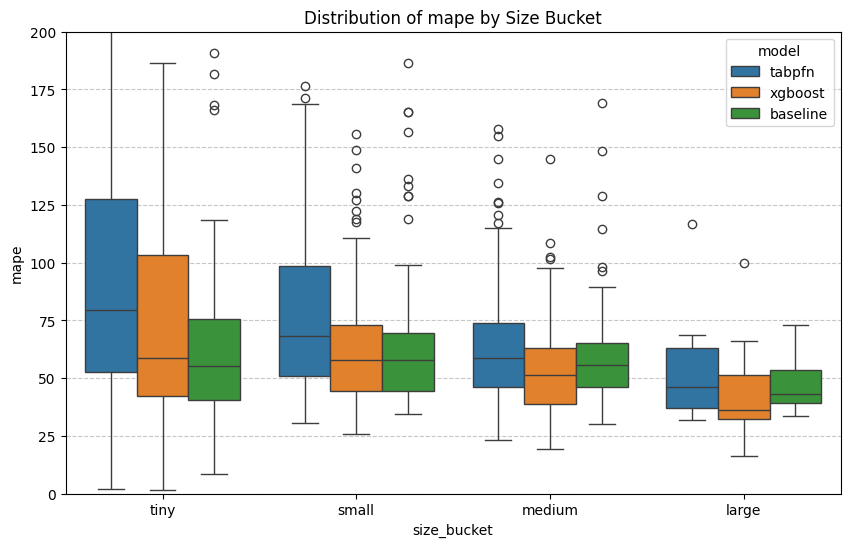

In [91]:
plot_box(df, ylim=(0, 200))

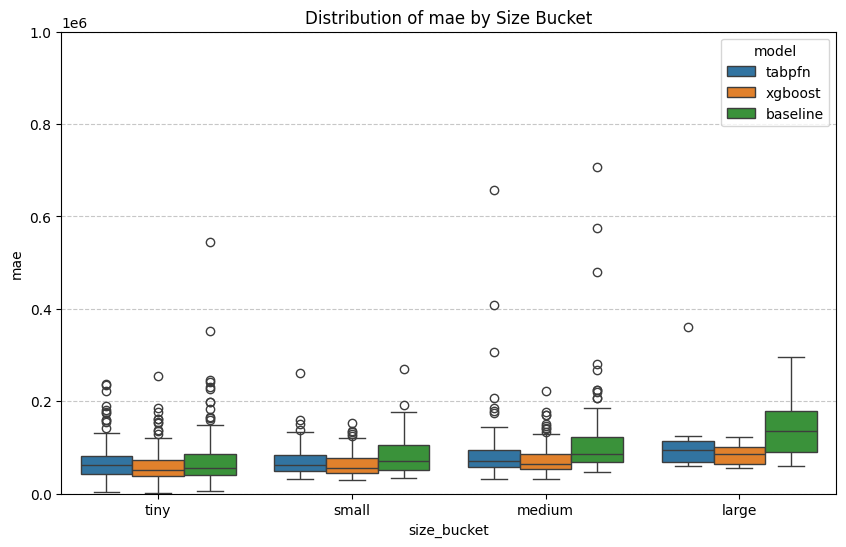

In [72]:
plot_box(df, 'mae', (0, 1e6))

# xgb on 5M

In [348]:
df_5m = pd.read_csv('../../results_temp/finetuning/xgboost_large_scale_train_v6/mape_values_filled_in.csv')
df = pd.concat([df_5m, baseline], ignore_index=True)

In [238]:
df_5m['test_fips'].nunique()

315

In [350]:
df[df['size_bucket'] == 'tiny']['test_fips']

1      31007.0
2      48169.0
3       1087.0
4      29083.0
5      28021.0
        ...   
96     28125.0
97     28041.0
98     48435.0
99      1041.0
100    30055.0
Name: test_fips, Length: 100, dtype: float64

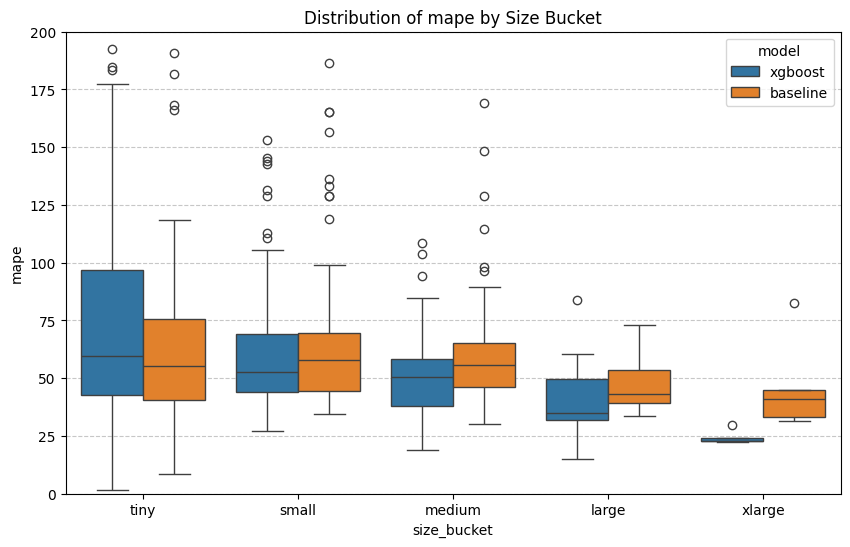

In [242]:
plot_box(df, ylim=(0, 200))

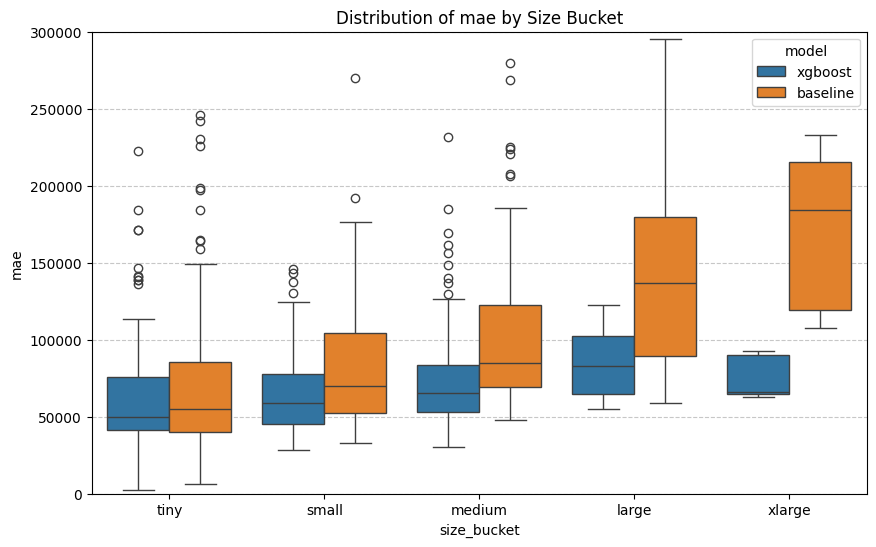

In [243]:
plot_box(df, 'mae', (0, 0.3e6))

In [ ]:
test_indices = np.load('../../data/test_v1/test_indices.npy')
train_pool_indices = np.load('../../data/test_v1/train_pool_indices.npy')
train_indices = np.load('../../data/test_v1/train_v6/train_indices.npy')

# Reconstruct the unique_indices array (sorted, deduplicated)
unique_indices = np.unique(np.concatenate([
    test_indices,
    train_pool_indices,
    train_indices
]))

In [34]:
def format_parquet(df):
    df['y_pred'] = np.exp(df['y_pred'].astype(float))
    df['y_true'] = np.exp(df['y_true'].astype(float))

    df['mae'] = (df['y_pred'] - df['y_true']).abs()
    df['mape'] = (df['y_pred'] - df['y_true']) / df['y_true']
    df['mape'] = df['mape'].abs()
    
    return df

In [260]:
xgb = pd.read_parquet('../../results_temp/finetuning/xgboost_large_scale_train_v6/predictions.parquet')
xgb = xgb.explode(['test_indices', 'y_true', 'y_pred']).reset_index(drop=True)
xgb = format_parquet(xgb)

baseline = pd.read_parquet('../../data/test_v1/baseline_predictions.parquet')
baseline = format_parquet(baseline)

In [275]:
test = pd.concat([xgb, baseline], ignore_index=True)

In [276]:
test

,model,test_indices,y_true,y_pred,mae,mape,data_row_index
0,xgboost,2516668,230000.0,226977.748922,3.022251e+03,0.013140,7551976
1,xgboost,2516669,159000.0,128115.300259,3.088470e+04,0.194243,7551977
2,xgboost,2516670,90000.0,167637.491018,7.763749e+04,0.862639,7551978
3,xgboost,2516673,85000.0,104520.593365,1.952059e+04,0.229654,7551981
4,xgboost,4370574,300000.0,419361.409838,1.193614e+05,0.397871,14570600
...,...,...,...,...,...,...,...
716157,baseline,1235730,1470000.0,337375.417750,1.132625e+06,0.770493,1235730
716158,baseline,1235731,686290.0,290107.686595,3.961823e+05,0.577281,1235731
716159,baseline,1235732,560400.0,73947.270702,4.864527e+05,0.868046,1235732
716160,baseline,1235733,503552.0,51676.197549,4.518758e+05,0.897377,1235733


Text(0.5, 1.0, 'Overall MAPE distribution (5M training points for XGB)')

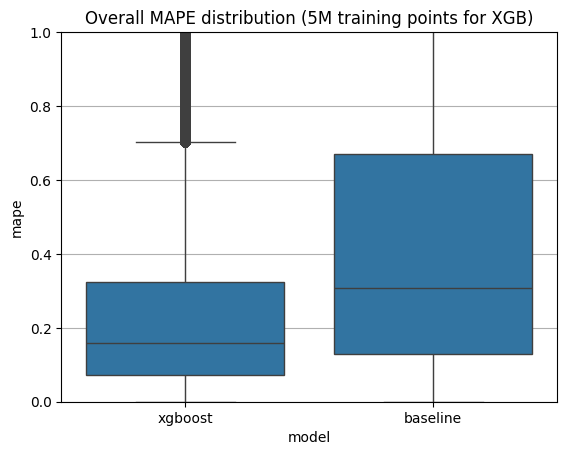

In [290]:
sns.boxplot(
    data=test,
    x='model',
    y='mape',
    fill=True,
)
plt.ylim(0, 1)
plt.grid()
plt.title('Overall MAPE distribution (5M training points for XGB)')

Text(0.5, 1.0, 'Overall MAE distribution (5M training points for XGB)')

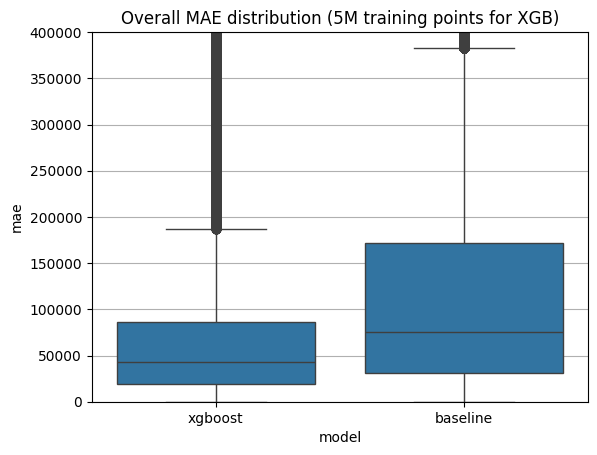

In [289]:
sns.boxplot(
    data=test,
    x='model',
    y='mae',
    fill=True,
)
plt.ylim(0, 0.4e6)
plt.grid()
plt.title('Overall MAE distribution (5M training points for XGB)')

In [ ]:
def plot_box(df, column='mape', ylim=None):
    # 1. Ensure logical order (Crucial so 'tiny' isn't alphabetical)
    category_order = ['tiny', 'small', 'medium', 'large', 'xlarge']
    df['size_bucket'] = pd.Categorical(df['size_bucket'], categories=category_order, ordered=True)

    # 2. Plot
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df, 
        x='size_bucket', 
        y=column, 
        hue='model',  # Adds color by bucket
        # palette='viridis',
        fill=True,          # Ensures the boxes are filled with color
    )
    if ylim:
        plt.ylim(ylim)

    plt.title(f'Distribution of {column} by Size Bucket')
    plt.grid(axis='y', linestyle='--', alpha=0.7) # Helps see values across categories
    plt.show()

In [261]:
xgb['data_row_index'] = unique_indices[xgb['test_indices'].astype(int).values]  # Convert finetuning indices
baseline['data_row_index'] = baseline['test_indices']  # Already correct

In [262]:
merged = xgb.merge(baseline, on='data_row_index', suffixes=('_xgb', '_baseline'))

In [291]:
merged

,model_xgb,test_indices_xgb,y_true_xgb,y_pred_xgb,mae_xgb,mape_xgb,data_row_index,model_baseline,test_indices_baseline,y_true_baseline,y_pred_baseline,mae_baseline,mape_baseline
0,xgboost,2516668,230000.0,226977.748922,3022.251078,0.013140,7551976,baseline,7551976,230000.0,206542.888971,2.345711e+04,0.101987
1,xgboost,2516669,159000.0,128115.300259,30884.699741,0.194243,7551977,baseline,7551977,159000.0,99444.485704,5.955551e+04,0.374563
2,xgboost,2516670,90000.0,167637.491018,77637.491018,0.862639,7551978,baseline,7551978,90000.0,33026.364649,5.697364e+04,0.633040
3,xgboost,2516673,85000.0,104520.593365,19520.593365,0.229654,7551981,baseline,7551981,85000.0,75099.888600,9.900111e+03,0.116472
4,xgboost,4370574,300000.0,419361.409838,119361.409838,0.397871,14570600,baseline,14570600,300000.0,163147.419235,1.368526e+05,0.456175
...,...,...,...,...,...,...,...,...,...,...,...,...,...
358076,xgboost,315311,1400000.0,535464.734912,864535.265088,0.617525,1235730,baseline,1235730,1470000.0,337375.417750,1.132625e+06,0.770493
358077,xgboost,315312,686290.0,486982.518565,199307.481435,0.290413,1235731,baseline,1235731,686290.0,290107.686595,3.961823e+05,0.577281
358078,xgboost,315313,560400.0,497083.950814,63316.049186,0.112984,1235732,baseline,1235732,560400.0,73947.270702,4.864527e+05,0.868046
358079,xgboost,315314,503552.0,557035.289338,53483.289338,0.106212,1235733,baseline,1235733,503552.0,51676.197549,4.518758e+05,0.897377


In [292]:
merged[merged['y_true_xgb'] == merged['y_true_baseline']]

,model_xgb,test_indices_xgb,y_true_xgb,y_pred_xgb,mae_xgb,mape_xgb,data_row_index,model_baseline,test_indices_baseline,y_true_baseline,y_pred_baseline,mae_baseline,mape_baseline
0,xgboost,2516668,230000.0,226977.748922,3022.251078,0.013140,7551976,baseline,7551976,230000.0,206542.888971,23457.111029,0.101987
1,xgboost,2516669,159000.0,128115.300259,30884.699741,0.194243,7551977,baseline,7551977,159000.0,99444.485704,59555.514296,0.374563
2,xgboost,2516670,90000.0,167637.491018,77637.491018,0.862639,7551978,baseline,7551978,90000.0,33026.364649,56973.635351,0.633040
3,xgboost,2516673,85000.0,104520.593365,19520.593365,0.229654,7551981,baseline,7551981,85000.0,75099.888600,9900.111400,0.116472
4,xgboost,4370574,300000.0,419361.409838,119361.409838,0.397871,14570600,baseline,14570600,300000.0,163147.419235,136852.580765,0.456175
...,...,...,...,...,...,...,...,...,...,...,...,...,...
358075,xgboost,315310,461400.0,623202.366991,161802.366991,0.350677,1235729,baseline,1235729,461400.0,164090.605273,297309.394727,0.644364
358077,xgboost,315312,686290.0,486982.518565,199307.481435,0.290413,1235731,baseline,1235731,686290.0,290107.686595,396182.313405,0.577281
358078,xgboost,315313,560400.0,497083.950814,63316.049186,0.112984,1235732,baseline,1235732,560400.0,73947.270702,486452.729298,0.868046
358079,xgboost,315314,503552.0,557035.289338,53483.289338,0.106212,1235733,baseline,1235733,503552.0,51676.197549,451875.802451,0.897377


In [265]:
test1 = merged[(merged['mae_xgb'] > merged['mae_baseline']) & (merged['mape_xgb'] < merged['mape_baseline'])]
test1

,model_xgb,test_indices_xgb,y_true_xgb,y_pred_xgb,mae_xgb,mape_xgb,data_row_index,model_baseline,test_indices_baseline,y_true_baseline,y_pred_baseline,mae_baseline,mape_baseline
14,xgboost,4370589,16000.0,98878.395109,82878.395109,5.179900,14570615,baseline,14570615,6000.0,54886.000743,48886.000743,8.147667
304,xgboost,4359891,16000.0,59460.343907,43460.343907,2.716271,14509912,baseline,14509912,6500.0,33538.804307,27038.804307,4.159816
345,xgboost,4797,16000.0,60110.202222,44110.202222,2.756888,35942,baseline,35942,6050.0,31682.138879,25632.138879,4.236717
360,xgboost,4622868,16000.0,161204.176449,145204.176449,9.075261,15425976,baseline,15425976,5584.0,64230.226513,58646.226513,10.502548
436,xgboost,4607318,16000.0,42892.874301,26892.874301,1.680805,15385949,baseline,15385949,10000.0,30189.379874,20189.379874,2.018938
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173587,xgboost,1674654,16000.0,54242.413283,38242.413283,2.390151,5250332,baseline,5250332,7500.0,28072.781285,20572.781285,2.743038
264151,xgboost,3337224,16000.0,117452.022456,101452.022456,6.340751,10574433,baseline,10574433,10000.0,107538.061641,97538.061641,9.753806
269001,xgboost,3346925,16000.0,128314.119493,112314.119493,7.019632,10584134,baseline,10584134,11000.0,120460.453026,109460.453026,9.950950
275826,xgboost,3360726,16000.0,127503.056345,111503.056345,6.968941,10597935,baseline,10597935,5100.0,51243.965837,46143.965837,9.047836


In [266]:
test2 = merged[(merged['mae_xgb'] < merged['mae_baseline']) & (merged['mape_xgb'] > merged['mape_baseline'])]
test2

,model_xgb,test_indices_xgb,y_true_xgb,y_pred_xgb,mae_xgb,mape_xgb,data_row_index,model_baseline,test_indices_baseline,y_true_baseline,y_pred_baseline,mae_baseline,mape_baseline
214,xgboost,842200,1400000.0,3.733639e+05,1.026636e+06,0.733311,3073300,baseline,3073300,2300000.0,6.512811e+05,1.648719e+06,0.716834
1876,xgboost,2516710,1400000.0,1.258753e+05,1.274125e+06,0.910089,7553789,baseline,7553789,1574000.0,1.440104e+05,1.429990e+06,0.908507
3138,xgboost,48031,1400000.0,1.177278e+05,1.282272e+06,0.915909,196495,baseline,196495,1569000.0,1.478351e+05,1.421165e+06,0.905777
3214,xgboost,1778466,1400000.0,6.400794e+05,7.599206e+05,0.542800,5508602,baseline,5508602,1837500.0,1.035128e+06,8.023719e+05,0.436665
3442,xgboost,2487051,1400000.0,9.568413e+05,4.431587e+05,0.316542,7504356,baseline,7504356,3500000.0,2.718307e+06,7.816933e+05,0.223341
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355206,xgboost,309951,1400000.0,1.192017e+06,2.079828e+05,0.148559,1230370,baseline,1230370,1600000.0,1.821426e+06,2.214259e+05,0.138391
356510,xgboost,312597,1400000.0,1.316972e+06,8.302755e+04,0.059305,1233016,baseline,1233016,2638000.0,2.788037e+06,1.500371e+05,0.056875
356718,xgboost,313015,1400000.0,1.145746e+06,2.542538e+05,0.181610,1233434,baseline,1233434,1670000.0,1.387740e+06,2.822599e+05,0.169018
356769,xgboost,313098,1400000.0,1.291610e+06,1.083905e+05,0.077422,1233517,baseline,1233517,2200000.0,2.368995e+06,1.689952e+05,0.076816


In [267]:
def plot_error_scaling(df, model_suffix='_x'):
    plt.figure(figsize=(10, 6))
    
    # Calculate Residuals
    df['residual'] = df['y_true'+model_suffix] - df['y_pred'+model_suffix]
    
    sns.scatterplot(data=df, x='y_true'+model_suffix, y='residual', alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    
    plt.title(f'Residuals vs Actuals for {model_suffix}')
    plt.xlabel('Actual Value (y_true)')
    plt.ylabel('Error (Residual)')
    plt.show()

/var/folders/5w/z16gwdx123l_m1mtmtq2mn380000gp/T/ipykernel_59322/421394770.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['residual'] = df['y_true'+model_suffix] - df['y_pred'+model_suffix]


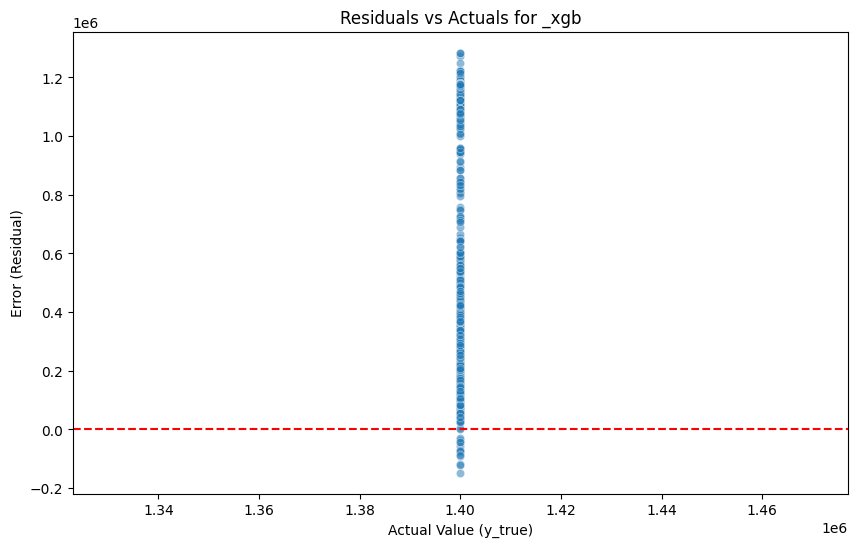

In [268]:
plot_error_scaling(test2, '_xgb')

/var/folders/5w/z16gwdx123l_m1mtmtq2mn380000gp/T/ipykernel_59322/421394770.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['residual'] = df['y_true'+model_suffix] - df['y_pred'+model_suffix]


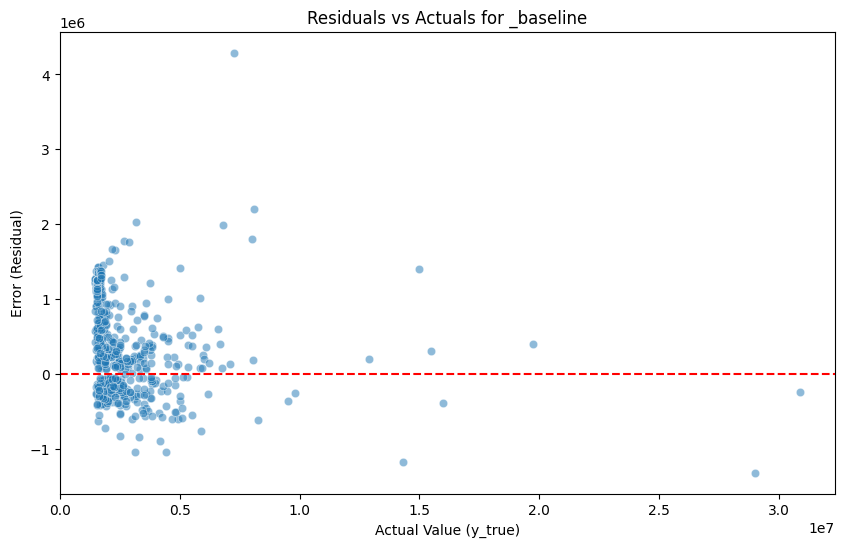

In [269]:
plot_error_scaling(test2, '_baseline')

/var/folders/5w/z16gwdx123l_m1mtmtq2mn380000gp/T/ipykernel_59322/421394770.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['residual'] = df['y_true'+model_suffix] - df['y_pred'+model_suffix]


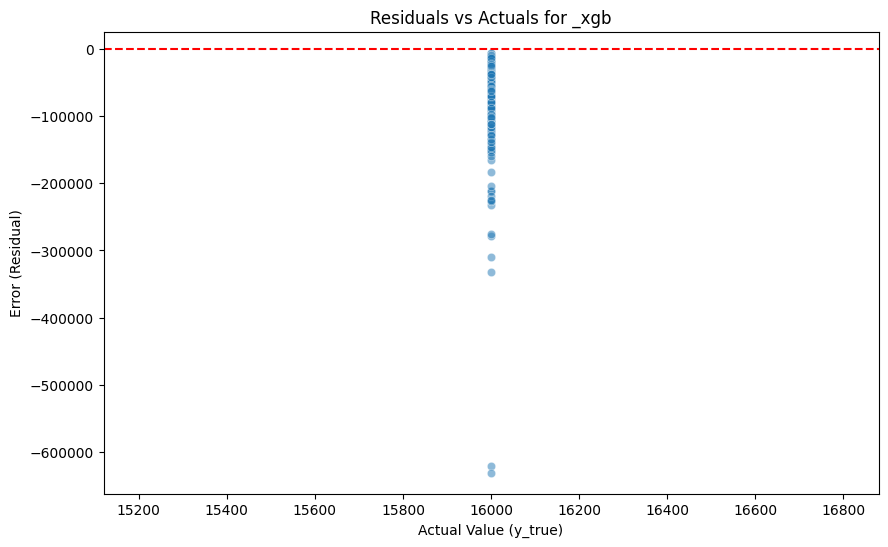

/var/folders/5w/z16gwdx123l_m1mtmtq2mn380000gp/T/ipykernel_59322/421394770.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['residual'] = df['y_true'+model_suffix] - df['y_pred'+model_suffix]


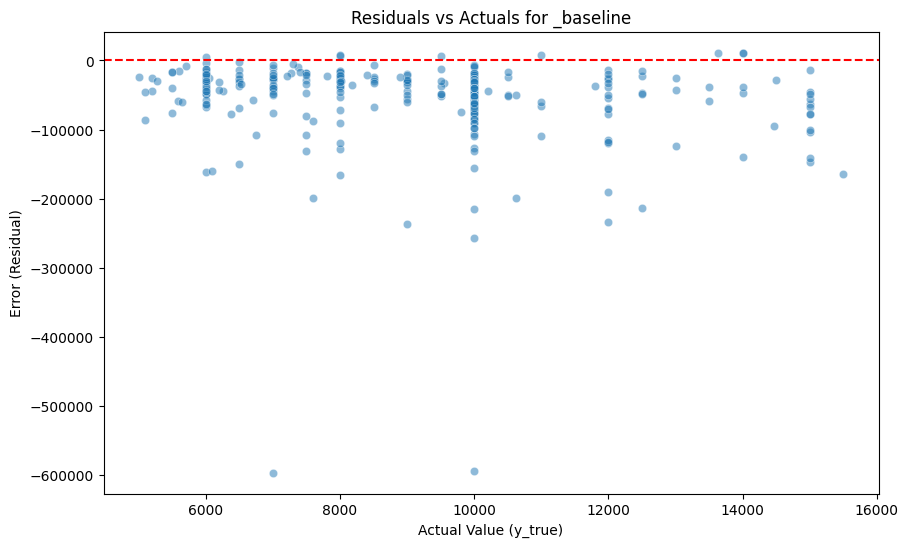

In [271]:
plot_error_scaling(test1, '_xgb')
plot_error_scaling(test1, '_baseline')

# Note about row matching

The XGBoost predictions are from the same test set. The test_index column just uses a different index scheme:                                                     
                                                                                                                                                                    
  - Baseline test_index: original data.parquet row indices (from test_indices.npy)
  - XGBoost test_index: iloc positions within a subset DataFrame created by finetuning.py                                                                           
                                                                                                                                                                    
  To convert XGBoost indices to data.parquet row indices:

  `unique_indices = np.unique(np.concatenate([
      np.load('.../test_v1/test_indices.npy'),
      np.load('.../test_v1/train_pool_indices.npy'),
      np.load('.../test_v1/train_v6/train_indices.npy'),
  ]))
  data_row_index = unique_indices[xgb_test_index]`

  To join the two prediction files at the row level:

  `xgb['data_row_index'] = unique_indices[xgb['test_index'].values]
  baseline['data_row_index'] = baseline['test_index']
  merged = xgb.merge(baseline, on='data_row_index', suffixes=('_xgb', '_baseline'))`

# tabpfn v2.5

In [341]:
df = pd.read_csv('../../results_temp/cross_county/test_v1_train_v4/test_v1_train_v4/mape_values_filled_in.csv')
df = pd.concat([df, baseline], ignore_index=True)

In [ ]:
# df = df[df['county_train_used'] > 0]

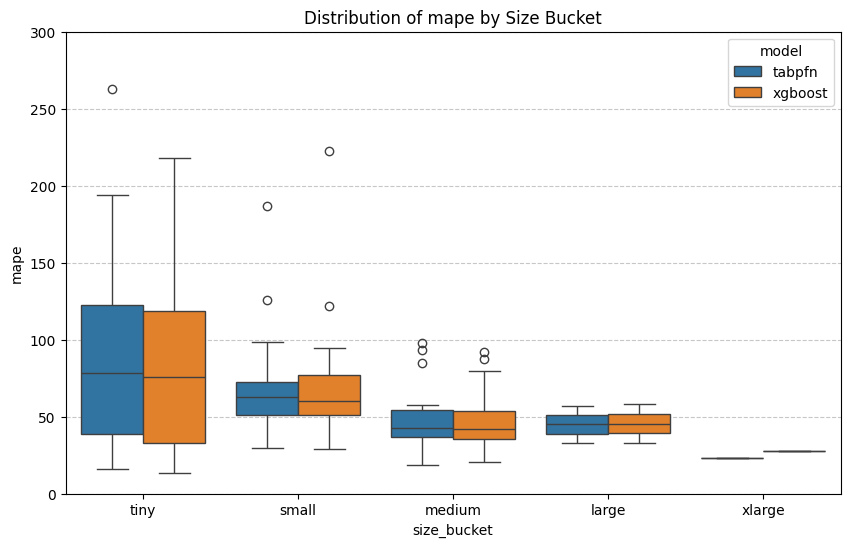

In [343]:
plot_box(df, ylim=(0, 300))

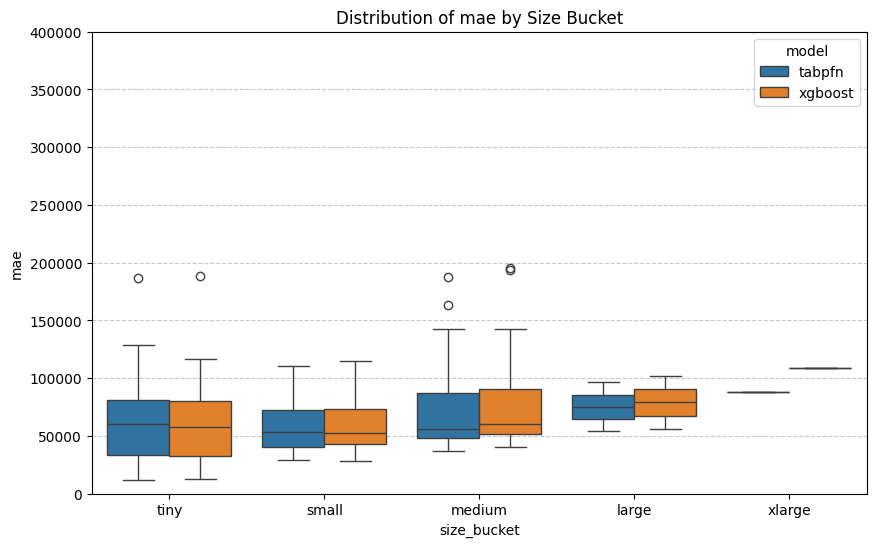

In [344]:
plot_box(df, 'mae', (0, 0.4e6))

In [345]:
test_indices = np.load('../../data/test_v1/test_indices.npy')
train_pool_indices = np.load('../../data/test_v1/train_pool_indices.npy')
train_indices = np.load('../../data/test_v1/train_v4/train_indices.npy')

# Reconstruct the unique_indices array (sorted, deduplicated)
unique_indices = np.unique(np.concatenate([
    test_indices,
    train_pool_indices,
    train_indices
]))

def format_parquet(df):
    df['y_pred'] = np.exp(df['y_pred'].astype(float))
    df['y_true'] = np.exp(df['y_true'].astype(float))

    df['mae'] = (df['y_pred'] - df['y_true']).abs()
    df['mape'] = (df['y_pred'] - df['y_true']) / df['y_true']
    df['mape'] = df['mape'].abs()
    
    return df

xgb = pd.read_parquet('../../results_temp/cross_county/test_v1_train_v4/predictions.parquet')
xgb = xgb.explode(['test_indices', 'y_true', 'y_pred']).reset_index(drop=True)
xgb = format_parquet(xgb)

baseline = pd.read_parquet('../../data/test_v1/baseline_predictions.parquet')
baseline = format_parquet(baseline)

test = pd.concat([xgb, baseline], ignore_index=True)

Text(0.5, 1.0, 'Overall MAPE distribution (50K training points)')

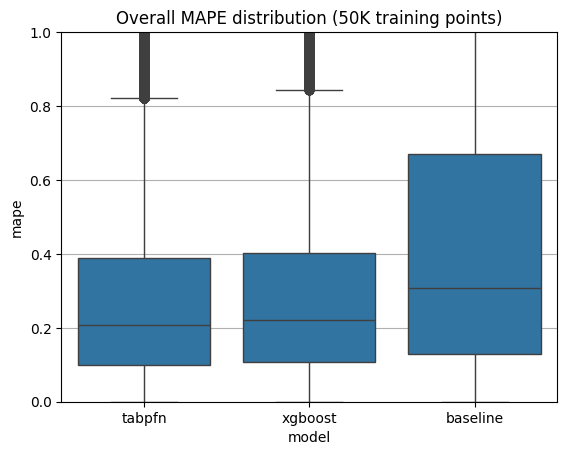

In [346]:
sns.boxplot(
    data=test,
    x='model',
    y='mape',
    fill=True,
)
plt.ylim(0, 1)
plt.grid()
plt.title('Overall MAPE distribution (50K training points)')

Text(0.5, 1.0, 'Overall MAE distribution (50K training points)')

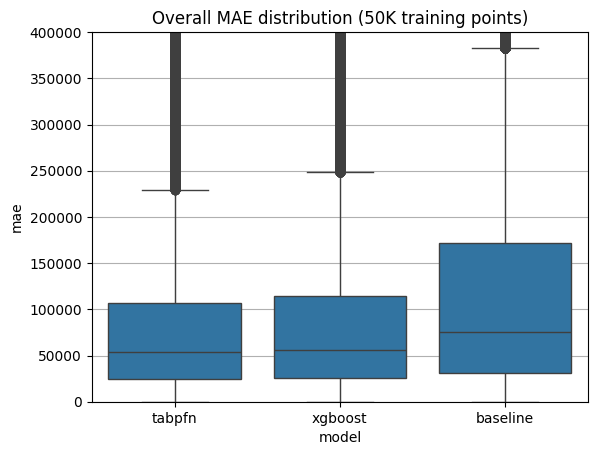

In [347]:
sns.boxplot(
    data=test,
    x='model',
    y='mae',
    fill=True,
)
plt.ylim(0, 0.4e6)
plt.grid()
plt.title('Overall MAE distribution (50K training points)')

# test_v1_train_v1

In [357]:
df = pd.read_csv('../../results_temp/cross_county/test_v1_train_v1/results.csv')
# df = pd.concat([df, baseline], ignore_index=True)

In [358]:
df

,model,train_size,test_size,n_features,fit_time,pred_time,r2,mae,rmse,mape,...,n_train_source_external,status,experiment_name,experiment_description,result_type,test_fips,size_bucket,county_test_size,county_train_pool_size,county_train_used
0,tabpfn,10000.0,358081.0,107.0,114.530052,3050.462168,0.554021,110291.892601,230092.129272,40.671041,...,0.0,success,test_v1_train_v1,"Size-stratified test, train on test-county his...",NaN,NaN,NaN,NaN,NaN,NaN
1,xgboost,10000.0,358081.0,107.0,2544.941132,0.138534,0.516661,119320.663965,239535.886050,39.948833,...,0.0,success,test_v1_train_v1,"Size-stratified test, train on test-county his...",NaN,NaN,NaN,NaN,NaN,NaN
2,tabpfn,NaN,NaN,NaN,NaN,NaN,0.612230,31908.113281,36816.433515,30.911904,...,NaN,NaN,test_v1_train_v1,"Size-stratified test, train on test-county his...",per_county,31007.0,tiny,4.0,3.0,0.0
3,xgboost,NaN,NaN,NaN,NaN,NaN,0.780187,25221.789063,27719.261435,24.648691,...,NaN,NaN,test_v1_train_v1,"Size-stratified test, train on test-county his...",per_county,31007.0,tiny,4.0,3.0,0.0
4,tabpfn,NaN,NaN,NaN,NaN,NaN,0.317979,86060.702175,111656.913280,111.533455,...,NaN,NaN,test_v1_train_v1,"Size-stratified test, train on test-county his...",per_county,48169.0,tiny,49.0,49.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,xgboost,NaN,NaN,NaN,NaN,NaN,0.303652,112711.618145,214853.409646,31.557423,...,NaN,NaN,test_v1_train_v1,"Size-stratified test, train on test-county his...",per_county,39049.0,xlarge,44063.0,43980.0,0.0
628,tabpfn,NaN,NaN,NaN,NaN,NaN,0.255975,89982.588678,181676.934900,37.738957,...,NaN,NaN,test_v1_train_v1,"Size-stratified test, train on test-county his...",per_county,29095.0,xlarge,25135.0,25102.0,0.0
629,xgboost,NaN,NaN,NaN,NaN,NaN,0.204112,97449.691231,187902.294189,37.751226,...,NaN,NaN,test_v1_train_v1,"Size-stratified test, train on test-county his...",per_county,29095.0,xlarge,25135.0,25102.0,0.0
630,tabpfn,NaN,NaN,NaN,NaN,NaN,0.395516,175370.206124,315750.954317,32.373527,...,NaN,NaN,test_v1_train_v1,"Size-stratified test, train on test-county his...",per_county,12071.0,xlarge,46850.0,46816.0,0.0


# per county scaling

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from pathlib import Path
# import seaborn as sns

# def analyze_per_county_scaling(df_all, 
#                                  metric='mae', 
#                                  figsize=(12, 6),
#                                  baseline_stats=None):
#     """
#     Analyze and plot learning curves across all counties.
    
#     Parameters:
#     -----------
#     base_path : str
#         Path to the directory containing county_* subdirectories
#     metric : str
#         Metric to plot ('mae' or 'mape')
#     figsize : tuple
#         Figure size for the plot
    
#     Returns:
#     --------
#     df_all : DataFrame
#         Combined results from all counties
#     stats_df : DataFrame
#         Statistics (median, Q1, Q3) per train size and model
#     """
    
#     # Calculate statistics per train size and model
#     stats = []
#     for model in ['tabpfn', 'xgboost', 'baseline']:
#         model_data = df_all[df_all['model'] == model]
#         for train_size in sorted(model_data['actual_train_size'].unique()):
#             size_data = model_data[model_data['actual_train_size'] == train_size][metric]
#             stats.append({
#                 'model': model,
#                 'train_size': train_size,
#                 'median': size_data.median(),
#                 'q1': size_data.quantile(0.25),
#                 'q3': size_data.quantile(0.75),
#                 'mean': size_data.mean(),
#                 'std': size_data.std(),
#                 'count': len(size_data)
#             })
    
#     stats_df = pd.DataFrame(stats)
#     if baseline_stats is not None:
#         stats_df = pd.concat([stats_df, baseline_stats], ignore_index=True)
    
#     # Create plot
#     fig, ax = plt.subplots(figsize=figsize)
    
#     for model, color in [('tabpfn', 'blue'), ('xgboost', 'red'), ('baseline', 'green')]:
#         model_stats = stats_df[stats_df['model'] == model].sort_values('train_size')
        
#         # Plot median line
#         ax.plot(model_stats['train_size'], model_stats['median'], 
#                 marker='o', label=f'{model} (median)', color=color, linewidth=2)
        
#         # Plot IQR shaded region
#         ax.fill_between(model_stats['train_size'], 
#                         model_stats['q1'], 
#                         model_stats['q3'], 
#                         alpha=0.3, color=color, label=f'{model} (IQR)')
    
#     ax.set_xlabel('Training Size', fontsize=12)
#     ax.set_ylabel(metric.upper(), fontsize=12)
#     ax.set_title(f'{metric.upper()} vs Training Size (Median and IQR across counties)', 
#                  fontsize=14)
#     ax.legend(loc='best')
#     ax.grid(True, alpha=0.3)
    
#     plt.tight_layout()
    
#     return df_all, stats_df, fig


In [24]:
def plot_model_diff_ci(
    df_all,
    model1='tabpfn',
    model2='xgboost',
    metric='mae',
    size_col='requested_train_size',  # or 'actual_train_size' if you prefer
    figsize=(12, 6)
):
    """
    Compare two models by computing per-(fips, size) differences and plotting
    mean +/- 2*SE vs training size.

    Parameters
    ----------
    df_all : pd.DataFrame
        Must contain columns: ['fips', size_col, 'model', metric].
    model1, model2 : str
        Names of the two models to compare (values in df_all['model']).
        Difference is computed as model1 - model2.
    metric : str
        Metric column to use (e.g. 'mae' or 'mape').
    size_col : str
        Column that encodes the training-size notion you want on the x-axis
        (e.g. 'requested_train_size' or 'actual_train_size').
    figsize : tuple
        Matplotlib figure size.

    Returns
    -------
    diffs_df : pd.DataFrame
        One row per (fips, size) where both models are present, with columns:
        ['fips', size_col, model1, model2, 'diff'].
    stats_df : pd.DataFrame
        Per-size summary with columns:
        [size_col, 'mean', 'std', 'count', 'se', 'ci_low', 'ci_high'].
    fig : matplotlib.figure.Figure
        The generated figure.
    """

    # Keep just the two models of interest
    df_sub = df_all[df_all['model'].isin([model1, model2])].copy()

    # Pivot so each (fips, size) row has both model metrics as columns
    pivot = (
        df_sub
        .pivot_table(
            index=['fips', size_col],
            columns='model',
            values=metric
        )
        .reset_index()
    )

    # Drop any rows where one of the models is missing
    pivot = pivot.dropna(subset=[model1, model2])

    # Compute difference model1 - model2
    pivot['diff'] = pivot[model1] - pivot[model2]

    # Per-size summary: mean, std, count, SE, and 95%-ish CI using 2*SE
    stats = (
        pivot
        .groupby(size_col)['diff']
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    stats['se'] = stats['std'] / np.sqrt(stats['count'])
    stats['ci_low'] = stats['mean'] - 2 * stats['se']
    stats['ci_high'] = stats['mean'] + 2 * stats['se']

    # Plot
    fig, ax = plt.subplots(figsize=figsize)

    x = stats[size_col].values
    y = stats['mean'].values
    yerr = 2 * stats['se'].values  # same as ci_high - mean

    ax.errorbar(
        x, y, yerr=yerr,
        fmt='-o',
        capsize=5,
        linewidth=2,
        label=f'{metric.upper()} difference: {model1} - {model2}'
    )

    ax.axhline(0, color='k', linestyle='--', alpha=0.5)

    ax.set_xlabel('Training Size', fontsize=12)
    ax.set_ylabel(f'{metric.upper()} difference', fontsize=12)
    ax.set_title(
        f'{metric.upper()} difference ({model1} - {model2}) vs Training Size\n'
        f'Mean ± 2·SE across counties',
        fontsize=14
    )
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

    plt.tight_layout()

    return pivot, stats, fig

In [10]:
def compute_baseline_per_training_size(df_all, baseline_results, metric='mae'):
    """
    For each unique training size in df_all, finds the FIPS codes present,
    looks them up in baseline_results, and computes median + IQR.
    
    Returns a DataFrame with columns: training_size, median, q25, q75
    """
    rows = []
    for train_size, group in df_all.groupby('requested_train_size'):
        fips_at_size = group['fips'].unique()
        baseline_subset = baseline_results[baseline_results['fips'].isin(fips_at_size)]
        if baseline_subset.empty:
            continue
        vals = baseline_subset[metric]
        rows.append({
            'train_size': train_size,
            'median': vals.median(),
            'q1': vals.quantile(0.25),
            'q3': vals.quantile(0.75),
        })
    df = pd.DataFrame(rows).sort_values('train_size').reset_index(drop=True)
    df['model'] = 'baseline'
    return df

preds_baseline = pd.read_parquet('../../data/test_v4/baseline_predictions.parquet')
preds_tabpfn = pd.read_parquet('/nlp/scr/salilg/property_tax/results/cross_county/test_v4_train_v1/predictions_tabpfn.parquet')
baseline_results = compute_baseline_metrics_from_winsorized_y_true(preds_baseline, preds_tabpfn).reset_index()

In [46]:
base_path = '../../results_temp/per_county_scaling/tiny_small'

base = Path(base_path)
csv_files = list(base.glob('county_*/results.csv'))

print(f"Found {len(csv_files)} county result files")

# Read and combine all results
dfs = []
for csv_file in csv_files:
    df = pd.read_csv(csv_file)
    county_id = csv_file.parent.name  # e.g., 'county_1013'
    df['county'] = county_id
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

Found 180 county result files


In [47]:
df_all = pd.read_csv('/nlp/scr/salilg/property_tax/results/per_county_scaling/test_v4/results.csv')

In [48]:
df_all

,fips,size_bucket,county_train_pool_size,county_test_size,requested_train_size,actual_train_size,seed,model,n_features,fit_time,pred_time,r2,mae,rmse,mape,mse,status,experiment_name,experiment_description
0,1011,small,68,18,5,5,42,tabpfn,107,7.318617,1.229466,-0.695801,47420.592278,56585.259001,79.722782,3.201892e+09,success,per_county_scaling_test_v4,Per-county learning curves for test_v4
1,1011,small,68,18,5,5,42,xgboost,107,24.303303,0.015225,-1.008521,52343.903693,61582.035942,95.650416,3.792347e+09,success,per_county_scaling_test_v4,Per-county learning curves for test_v4
2,1011,small,68,18,10,10,42,tabpfn,107,1.018223,0.308450,-1.139118,171737.505680,247560.477952,190.965807,6.128619e+10,success,per_county_scaling_test_v4,Per-county learning curves for test_v4
3,1011,small,68,18,10,10,42,xgboost,107,24.585517,0.014611,0.055393,89942.847206,164508.995803,64.902441,2.706321e+10,success,per_county_scaling_test_v4,Per-county learning curves for test_v4
4,1011,small,68,18,20,20,42,tabpfn,107,1.006737,0.302279,0.939738,32073.974573,41550.427624,44.777383,1.726438e+09,success,per_county_scaling_test_v4,Per-county learning curves for test_v4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
917,56013,tiny,29,8,5,5,42,xgboost,107,23.953847,0.015626,-0.005638,17665.780284,17948.534495,9.401024,3.221499e+08,success,per_county_scaling_test_v4,Per-county learning curves for test_v4
918,56013,tiny,29,8,10,10,42,tabpfn,107,0.939903,0.293509,0.412478,40491.226944,48681.557030,22.765868,2.369894e+09,success,per_county_scaling_test_v4,Per-county learning curves for test_v4
919,56013,tiny,29,8,10,10,42,xgboost,107,20.886175,0.013726,-0.026613,55210.396866,64351.094183,29.771869,4.141063e+09,success,per_county_scaling_test_v4,Per-county learning curves for test_v4
920,56013,tiny,29,8,20,20,42,tabpfn,107,1.029166,0.294691,-0.652315,59354.677603,79064.566745,27.206399,6.251206e+09,success,per_county_scaling_test_v4,Per-county learning curves for test_v4


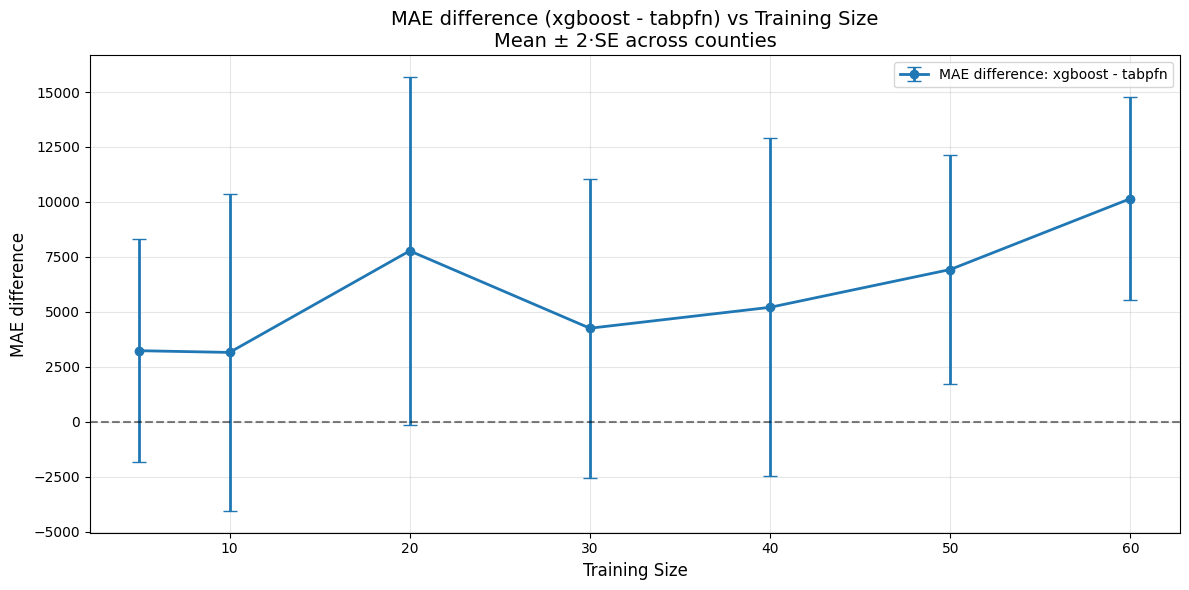

In [30]:
_, _, _ = plot_model_diff_ci(df_all, model1='xgboost', model2='tabpfn', metric='mae')

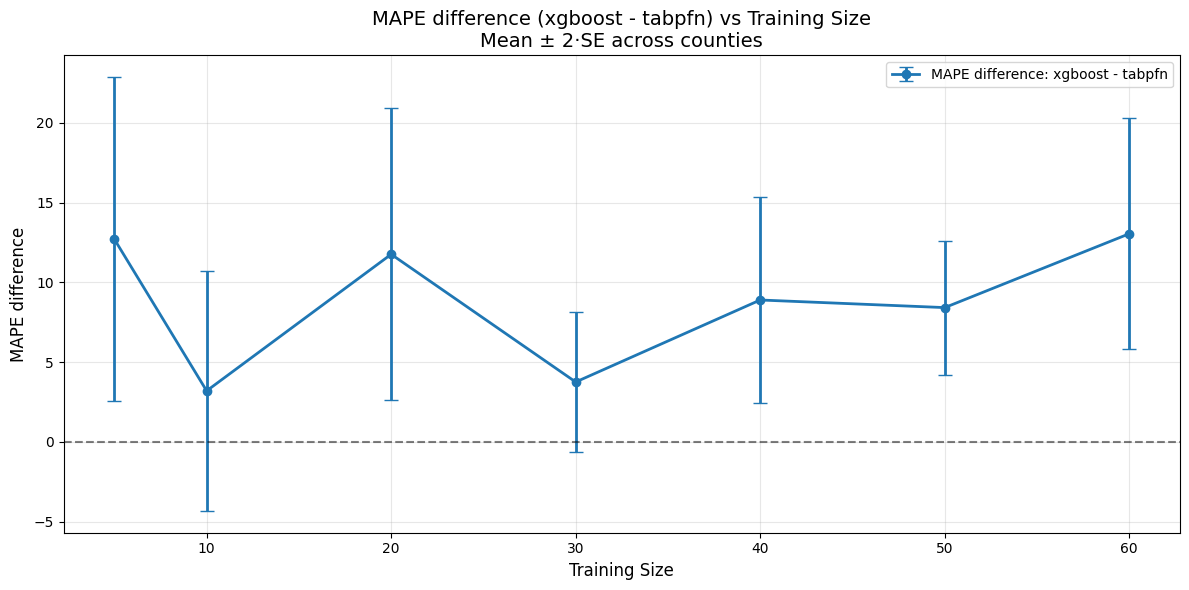

In [27]:
_, _, _ = plot_model_diff_ci(df_all, model1='xgboost', model2='tabpfn', metric='mape')

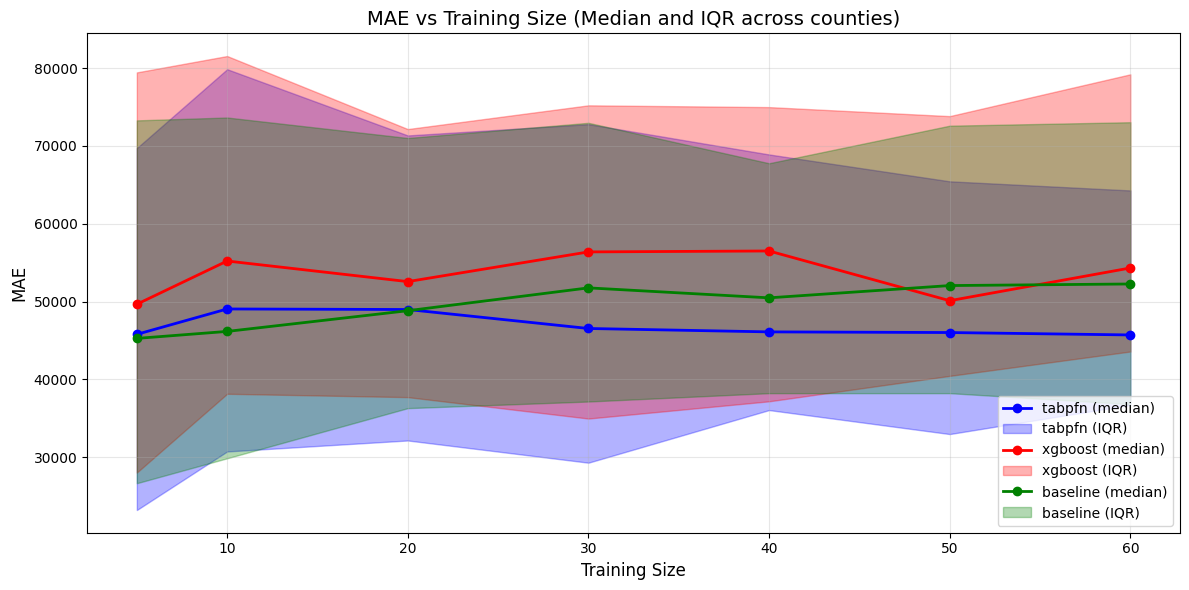

In [22]:
baseline_stats = compute_baseline_per_training_size(df_all, baseline_results, metric='mae')
df_all, stats_df, fig = analyze_per_county_scaling(df_all, metric='mae', baseline_stats=baseline_stats)



Found 180 county result files


/nlp/scr/salilg/miniconda3/envs/tabpfn_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


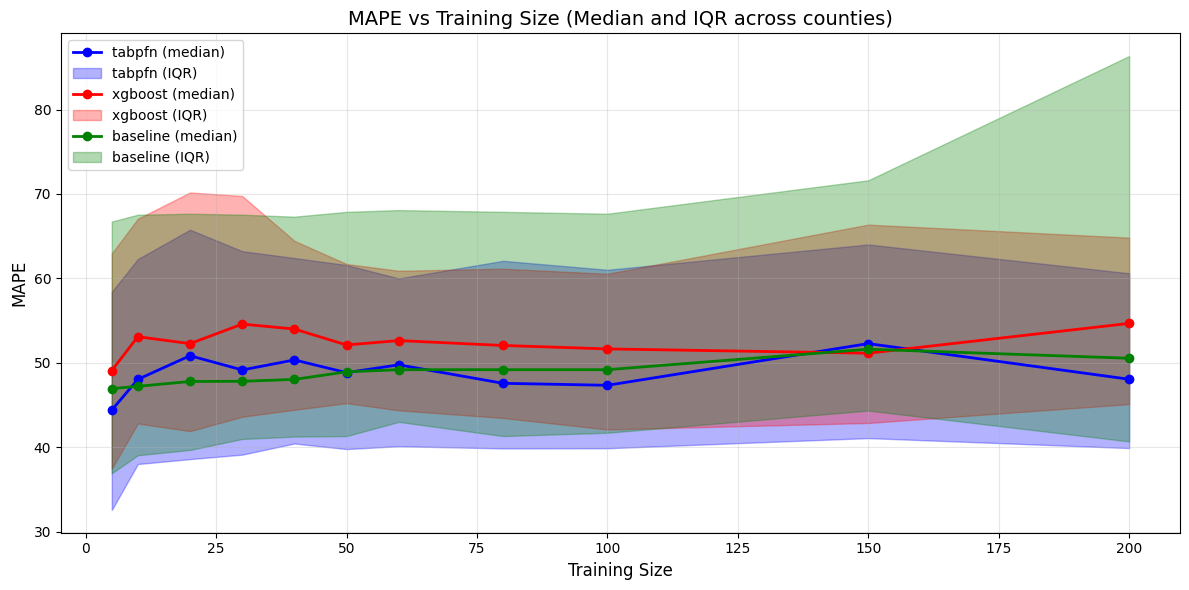

In [54]:
baseline_stats = compute_baseline_per_training_size(df_all, baseline_results, metric='mape')
df_all, stats_df, fig = analyze_per_county_scaling(metric='mape', baseline_stats=baseline_stats)

# test_v4_train_v1

In [81]:
# some gymnastics so that the baseline MAE and MAPE are computed from the winsorized y_true

def compute_baseline_metrics_from_winsorized_y_true(preds_baseline, preds_tabpfn):

    # preds_baseline = pd.read_parquet('../../data/test_v4/baseline_predictions.parquet')
    # preds_tabpfn = pd.read_parquet('../../results_temp/cross_county/test_v4_train_v1/predictions_tabpfn.parquet')


    preds_baseline['y_pred'] = np.exp(preds_baseline['y_pred'].astype(float))
    preds_tabpfn['y_true'] = np.exp(preds_tabpfn['y_true'].astype(float))
    merged = preds_baseline[['test_index', 'fips', 'size_bucket', 'y_pred']].merge(
        preds_tabpfn[['test_index', 'y_true']],  # winsorized y_true
        on='test_index'
    )
    merged = format_parquet(merged)
    baseline_results = merged.groupby(['fips', 'size_bucket'])[['mae', 'mape']].mean()
    baseline_results['model'] = 'baseline'
    baseline_results.rename(columns={'fips': 'test_fips'}, inplace=True)
    baseline_results['mape'] *= 100

    return baseline_results

In [92]:
# results = pd.read_csv('/nlp/scr/salilg/property_tax/results/cross_county/test_v4_train_v1/results.csv')
results = pd.read_csv('/nlp/scr/salilg/property_tax/results/cross_county/test_v4_train_v1_medium/results.csv')
preds_baseline = pd.read_parquet('../../data/test_v4/baseline_predictions.parquet')
preds_tabpfn = pd.read_parquet('/nlp/scr/salilg/property_tax/results/cross_county/test_v4_train_v1/predictions_tabpfn.parquet')
baseline_results = compute_baseline_metrics_from_winsorized_y_true(preds_baseline, preds_tabpfn)

df = pd.concat([results, baseline_results.reset_index()], ignore_index=True)

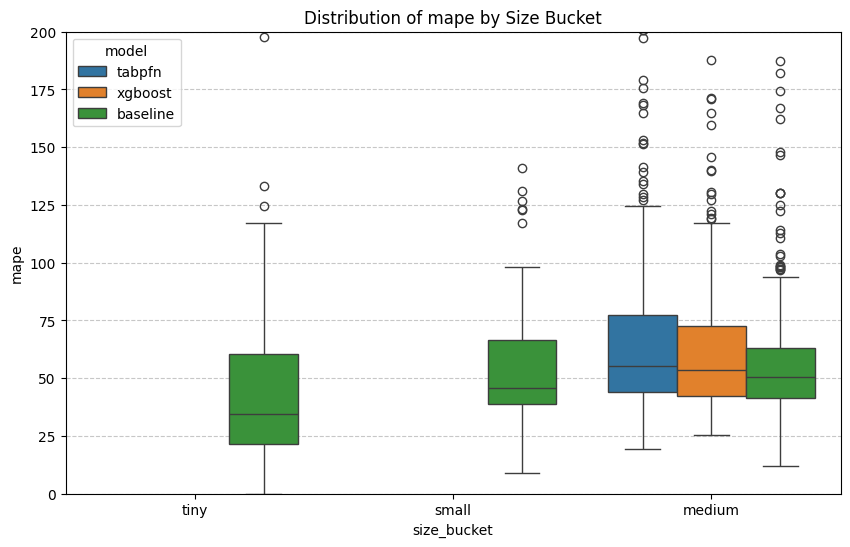

In [95]:
plot_box(df, 'mape', ylim=(0, 200))

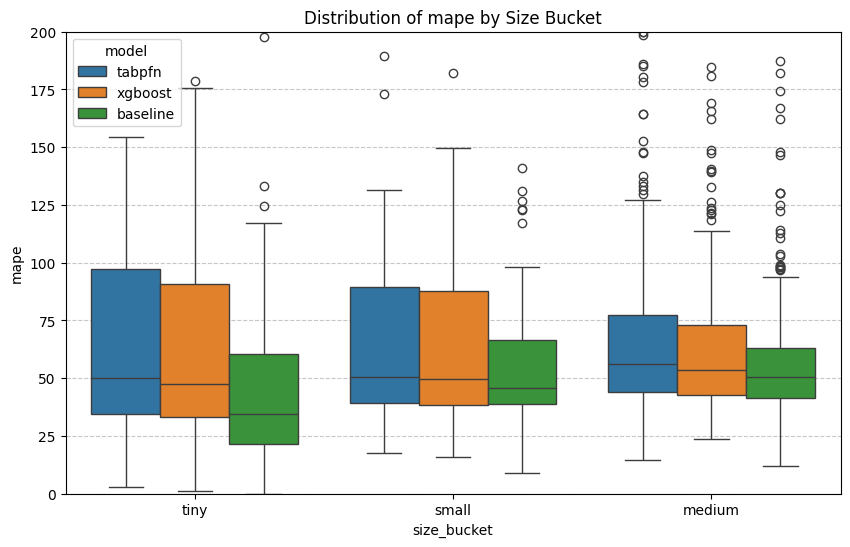

In [66]:
plot_box(df, ylim=(0, 200))

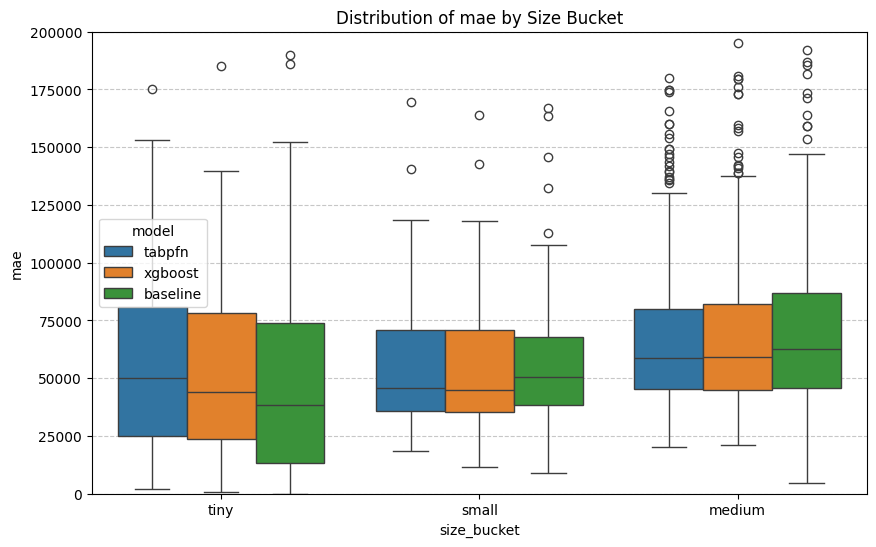

In [67]:
plot_box(df, 'mae', (0, 0.2e6))

### only counties that were included in the training data

In [21]:
df2 = df[df['county_train_used'] > 0]
fips_used = df2['test_fips'].unique()
baseline_results = baseline_results.reset_index()
baseline_used = baseline_results[baseline_results['fips'].isin(fips_used)]

df2 = pd.concat([df2, baseline_used], ignore_index=True)

In [22]:
df2

,model,train_size,test_size,n_features,fit_time,pred_time,r2,mae,rmse,mape,...,experiment_name,experiment_description,result_type,test_fips,size_bucket,county_test_size,county_train_pool_size,county_train_used,fips,index
0,tabpfn,NaN,NaN,NaN,NaN,NaN,NaN,37844.920469,37844.920469,42.401994,...,test_v4_train_v1,"Size-stratified test, train on test-county his...",per_county,48033.0,tiny,1.0,2.0,2.0,NaN,NaN
1,xgboost,NaN,NaN,NaN,NaN,NaN,NaN,35899.385313,35899.385313,40.222189,...,test_v4_train_v1,"Size-stratified test, train on test-county his...",per_county,48033.0,tiny,1.0,2.0,2.0,NaN,NaN
2,tabpfn,NaN,NaN,NaN,NaN,NaN,NaN,111203.437500,111203.437500,16.474583,...,test_v4_train_v1,"Size-stratified test, train on test-county his...",per_county,9001.0,tiny,1.0,1.0,1.0,NaN,NaN
3,xgboost,NaN,NaN,NaN,NaN,NaN,NaN,286559.250000,286559.250000,42.453222,...,test_v4_train_v1,"Size-stratified test, train on test-county his...",per_county,9001.0,tiny,1.0,1.0,1.0,NaN,NaN
4,tabpfn,NaN,NaN,NaN,NaN,NaN,0.20777,19124.552517,20273.001654,137.085075,...,test_v4_train_v1,"Size-stratified test, train on test-county his...",per_county,21189.0,tiny,9.0,32.0,32.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,baseline,NaN,NaN,NaN,NaN,NaN,NaN,9375.000000,NaN,11.718750,...,NaN,NaN,NaN,NaN,tiny,NaN,NaN,NaN,51137.0,475.0
194,baseline,NaN,NaN,NaN,NaN,NaN,NaN,25912.256586,NaN,62.289987,...,NaN,NaN,NaN,NaN,medium,NaN,NaN,NaN,54007.0,491.0
195,baseline,NaN,NaN,NaN,NaN,NaN,NaN,24167.257784,NaN,70.762853,...,NaN,NaN,NaN,NaN,medium,NaN,NaN,NaN,54059.0,502.0
196,baseline,NaN,NaN,NaN,NaN,NaN,NaN,68234.118948,NaN,48.817152,...,NaN,NaN,NaN,NaN,medium,NaN,NaN,NaN,54075.0,507.0


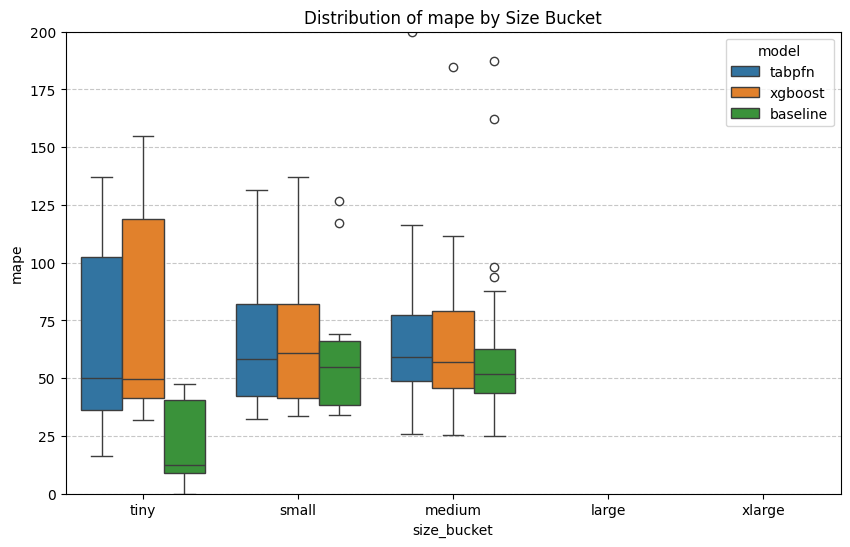

In [26]:
plot_box(df2, 'mape', (0, 200))

### box  plot including per-county results as well

In [124]:
def get_best_per_fips(df_all):
    """
    For each (fips, model), keep only the row with the highest requested_train_size.
    Returns a DataFrame formatted like df_all with model names suffixed '_best'.
    """
    idx = df_all.groupby(['fips', 'model'])['requested_train_size'].idxmax()
    best = df_all.loc[idx].copy()
    best['model'] = best['model'] + '_nopooling'
    return best


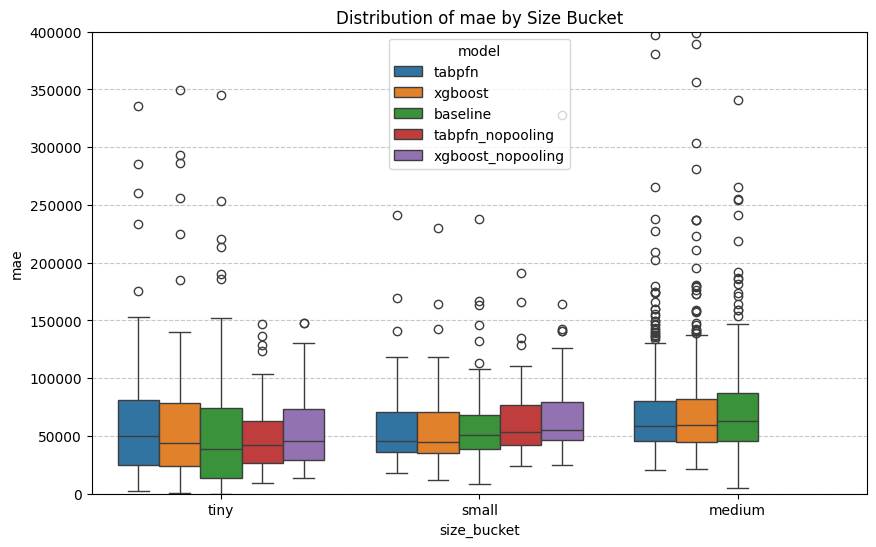

In [125]:
df_best = get_best_per_fips(df_all)
df_combined = pd.concat([df, df_best], ignore_index=True)
plot_box(df_combined, column='mae', ylim=(0, 0.4e6))


In [82]:
df_combined

,model,train_size,test_size,n_features,fit_time,pred_time,r2,mae,rmse,mape,...,test_fips,size_bucket,county_test_size,county_train_pool_size,county_train_used,fips,requested_train_size,actual_train_size,seed,county
0,tabpfn,10000.0,25281.0,107.0,25.315424,313.848164,0.529905,71854.441556,131733.492186,69.004914,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,xgboost,10000.0,25281.0,107.0,79.377560,0.044655,0.479300,74426.084346,138642.739674,64.688432,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,tabpfn,NaN,NaN,NaN,NaN,NaN,0.332402,83818.741071,136929.845844,40.583443,...,28115.0,tiny,7.0,26.0,0.0,NaN,NaN,NaN,NaN,NaN
3,xgboost,NaN,NaN,NaN,NaN,NaN,0.210077,95498.167411,148947.402732,51.071719,...,28115.0,tiny,7.0,26.0,0.0,NaN,NaN,NaN,NaN,NaN
4,tabpfn,NaN,NaN,NaN,NaN,NaN,0.476172,125826.503906,211523.396177,42.407354,...,1041.0,tiny,4.0,13.0,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1932,xgboost_nopooling,NaN,NaN,107.0,9.099423,0.006419,0.370203,21427.420680,31695.706286,54.336801,...,NaN,tiny,24.0,24.0,NaN,54101.0,20.0,20.0,42.0,county_54101
1933,tabpfn_nopooling,NaN,NaN,107.0,0.572299,0.210992,0.027583,51767.525121,82412.645856,62.239352,...,NaN,tiny,47.0,47.0,NaN,54105.0,40.0,40.0,42.0,county_54105
1934,xgboost_nopooling,NaN,NaN,107.0,12.578933,0.006593,-0.058190,52011.072141,85970.487198,56.388547,...,NaN,tiny,47.0,47.0,NaN,54105.0,40.0,40.0,42.0,county_54105
1935,tabpfn_nopooling,NaN,NaN,107.0,0.613142,0.692887,0.609104,77936.426387,113911.978473,30.752130,...,NaN,small,219.0,219.0,NaN,56035.0,200.0,200.0,42.0,county_56035


### including dummy predictor

In [146]:
preds_tabpfn = pd.read_parquet('/nlp/scr/salilg/property_tax/results/cross_county/test_v4_train_v1/predictions_tabpfn.parquet')
preds_tabpfn = format_parquet(preds_tabpfn, exponentiate=True)
preds_tabpfn_dummy = preds_tabpfn.groupby(['fips'])[['y_true']].mean().reset_index().rename(columns={'y_true': 'y_pred_dummy'})

preds_tabpfn = pd.merge(preds_tabpfn, preds_tabpfn_dummy, on='fips')

preds_tabpfn.drop(columns=['y_pred', 'mae', 'mape'], inplace=True)
preds_tabpfn['mae'] = (preds_tabpfn['y_true'] - preds_tabpfn['y_pred_dummy']).abs()
preds_tabpfn['mape'] = (preds_tabpfn['y_true'] - preds_tabpfn['y_pred_dummy']).abs() / preds_tabpfn['y_true']
preds_tabpfn['model'] = 'dummy'
preds_tabpfn.drop(columns=['y_true', 'y_pred_dummy'], inplace=True)

aggregated = preds_tabpfn.groupby(['fips', 'size_bucket', 'model'])[['mae', 'mape']].mean().reset_index()
aggregated.rename(columns={'fips': 'test_fips'}, inplace=True)
aggregated['mape'] *= 100

In [148]:
concatted = pd.concat([df_combined, aggregated], ignore_index=True)

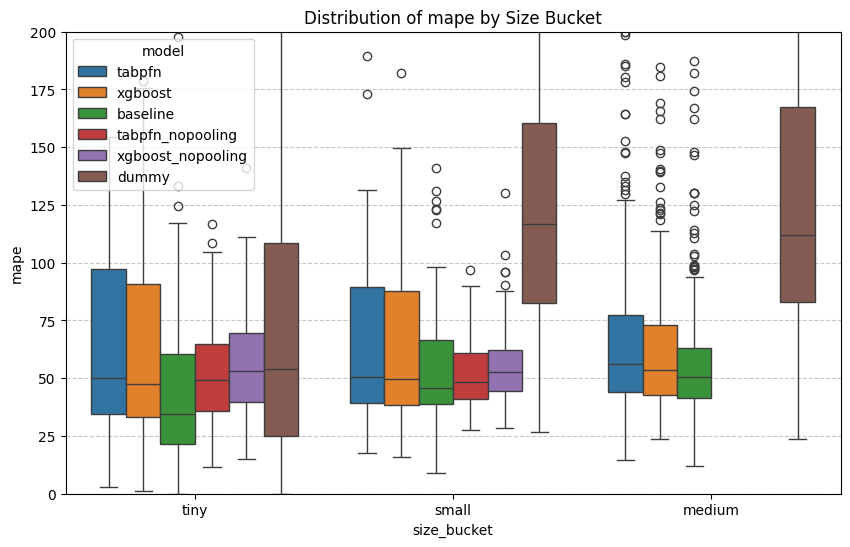

In [149]:
plot_box(concatted, column='mape', ylim=(0, 200))

### individual level predictions

In [77]:
preds_tabpfn = pd.read_parquet('/nlp/scr/salilg/property_tax/results/cross_county/test_v4_train_v1/predictions_tabpfn.parquet')
preds_tabpfn = format_parquet(preds_tabpfn, exponentiate=True)
preds_xgboost = pd.read_parquet('/nlp/scr/salilg/property_tax/results/cross_county/test_v4_train_v1/predictions_xgboost.parquet')
preds_xgboost = format_parquet(preds_xgboost, exponentiate=True)
# baseline = pd.read_parquet('../../data/test_v4/baseline_predictions.parquet')
# baseline = format_parquet(baseline)
preds_baseline = pd.read_parquet('../../data/test_v4/baseline_predictions.parquet')

preds_baseline['y_pred'] = np.exp(preds_baseline['y_pred'].astype(float))
# preds_tabpfn['y_true'] = np.exp(preds_tabpfn['y_true'].astype(float))
merged = preds_baseline[['test_index', 'fips', 'size_bucket', 'y_pred']].merge(
    preds_tabpfn[['test_index', 'y_true']],  # winsorized y_true
    on='test_index'
)
merged = format_parquet(merged)

indiv = pd.merge(preds_tabpfn, preds_xgboost, on='test_index', suffixes=('_tabpfn', '_xgboost'))
indiv = pd.merge(indiv, merged, on='test_index')

In [74]:
indiv[(indiv['mae_tabpfn'] < indiv['mae_xgboost']) & (indiv['mape_tabpfn'] > indiv['mape_xgboost'])]

,test_index,fips_tabpfn,size_bucket_tabpfn,y_true_tabpfn,y_pred_tabpfn,mae_tabpfn,mape_tabpfn,fips_xgboost,size_bucket_xgboost,y_true_xgboost,y_pred_xgboost,mae_xgboost,mape_xgboost,fips,size_bucket,y_pred,y_true,mae,mape


In [75]:
indiv

,test_index,fips_tabpfn,size_bucket_tabpfn,y_true_tabpfn,y_pred_tabpfn,mae_tabpfn,mape_tabpfn,fips_xgboost,size_bucket_xgboost,y_true_xgboost,y_pred_xgboost,mae_xgboost,mape_xgboost,fips,size_bucket,y_pred,y_true,mae,mape
0,7099034,28115,tiny,inf,220339.984646,5660.015354,0.025044,28115,tiny,2.260000e+05,195026.002725,30973.997275,0.137053,28115,tiny,4.349441e+05,inf,inf,NaN
1,7099036,28115,tiny,inf,103958.824671,33958.824671,0.485126,28115,tiny,7.000000e+04,114828.561574,44828.561574,0.640408,28115,tiny,1.748205e+05,inf,inf,NaN
2,7099039,28115,tiny,inf,151558.238501,23441.761499,0.133953,28115,tiny,1.750000e+05,146617.185945,28382.814055,0.162188,28115,tiny,2.410295e+05,inf,inf,NaN
3,7099040,28115,tiny,inf,271691.513918,278308.486082,0.506015,28115,tiny,5.500000e+05,226784.962442,323215.037558,0.587664,28115,tiny,5.053736e+05,inf,inf,NaN
4,7099042,28115,tiny,inf,30834.560960,227734.439040,0.880749,28115,tiny,2.585690e+05,42661.604864,215907.395136,0.835009,28115,tiny,1.419441e+04,inf,inf,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25276,17830638,8091,medium,inf,797214.161803,162214.161803,0.255455,8091,medium,6.350000e+05,859473.178828,224473.178828,0.353501,8091,medium,7.371914e+05,inf,inf,NaN
25277,17830641,8091,medium,inf,971137.565766,11137.565766,0.011602,8091,medium,9.600000e+05,873860.875193,86139.124807,0.089728,8091,medium,1.403253e+06,inf,inf,NaN
25278,17830649,8091,medium,inf,965015.649384,55015.649384,0.060457,8091,medium,9.100000e+05,865027.837756,44972.162244,0.049420,8091,medium,1.177772e+06,inf,inf,NaN
25279,17830653,8091,medium,inf,976414.227741,94180.180948,0.087970,8091,medium,1.070594e+06,905357.736893,165236.671796,0.154341,8091,medium,2.787585e+06,inf,inf,NaN


In [156]:
grouped =indiv.groupby(['fips', 'size_bucket'])[['mae_tabpfn', 'mae_xgboost', 'mae', 'mape_tabpfn', 'mape_xgboost', 'mape']].mean()

In [180]:
grouped[(grouped['mae'] > grouped['mae_xgboost']) & (grouped['mape'] < grouped['mape_xgboost'])]

,,mae_tabpfn,mae_xgboost,mae,mape_tabpfn,mape_xgboost,mape
fips,size_bucket,,,,,,
1025,medium,32672.674987,33801.312532,35390.244725,0.641598,0.644876,0.605128
1037,medium,104788.656641,103550.304648,104569.166210,0.779582,0.674776,0.669665
1107,medium,52501.389595,51881.029050,56757.915640,0.703807,0.762279,0.567039
1131,medium,65542.105496,56248.005669,63716.381524,1.195993,0.936458,0.565164
2100,small,88619.086063,77238.627342,87335.432754,0.471652,0.377564,0.369276
...,...,...,...,...,...,...,...
54085,medium,55650.132349,55372.243702,56382.033433,1.295323,1.226833,0.983802
54087,medium,75794.462072,71736.906116,75953.057196,1.105853,0.975516,0.896966
54089,small,33117.987958,33332.304864,36277.975548,0.895495,0.892362,0.772980


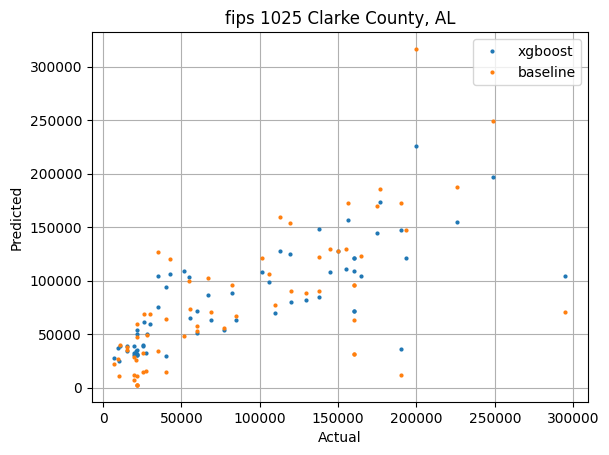

In [185]:
test = indiv[indiv['fips'] == 1025]
plt.plot(test['y_true_xgboost'], test['y_pred_xgboost'], 'o', label='xgboost', markersize=2)
plt.plot(test['y_true'], test['y_pred'], 'o', label='baseline', markersize=2)
plt.grid()
plt.legend()
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('fips 1025 Clarke County, AL');

In [183]:
test['mae_xgboost'].mean(), test['mae'].mean()

(np.float64(33801.31253174968), np.float64(35390.24472542117))

In [184]:
test['mape_xgboost'].mean(), test['mape'].mean()

(np.float64(0.6448761882672169), np.float64(0.6051283372220879))

# test_v5_train_v1

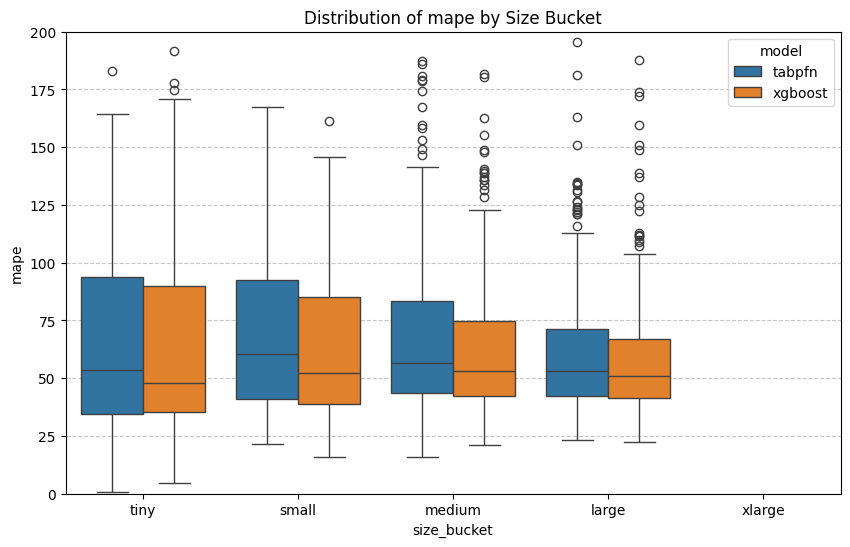

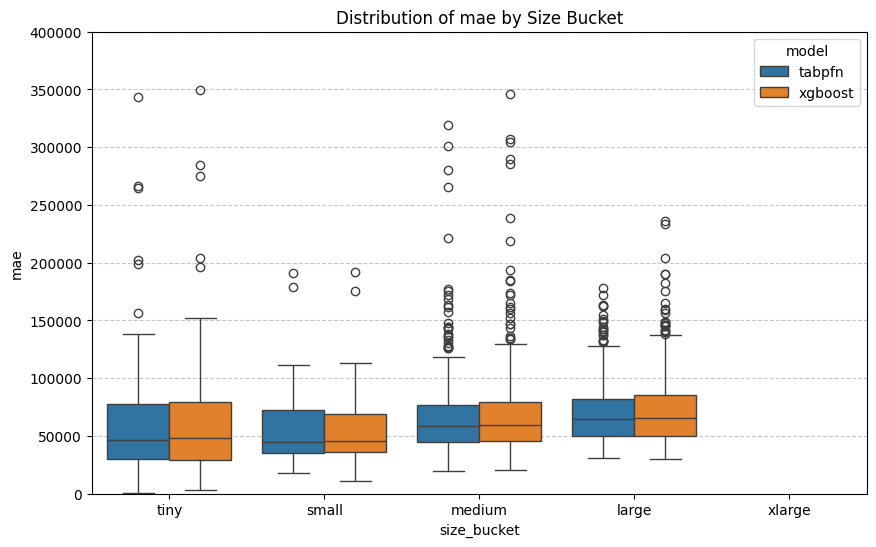

In [401]:
df = pd.read_csv('../../results_temp/cross_county/test_v5_train_v1/results.csv')
# baseline = pd.read_csv('../../data/test_v5/baseline_results.csv')
# df = pd.concat([df, baseline], ignore_index=True)
plot_box(df, ylim=(0, 200))
plot_box(df, 'mae', (0, 0.4e6))

# test_v4_train_v7

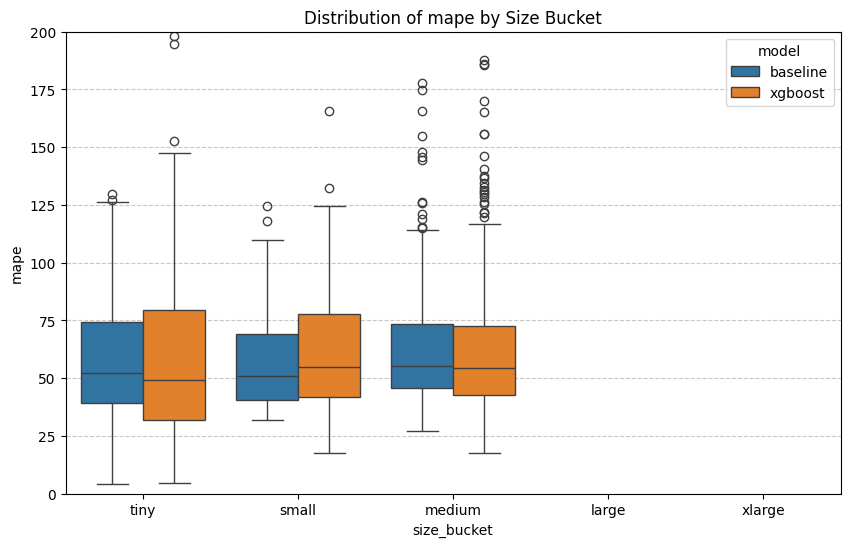

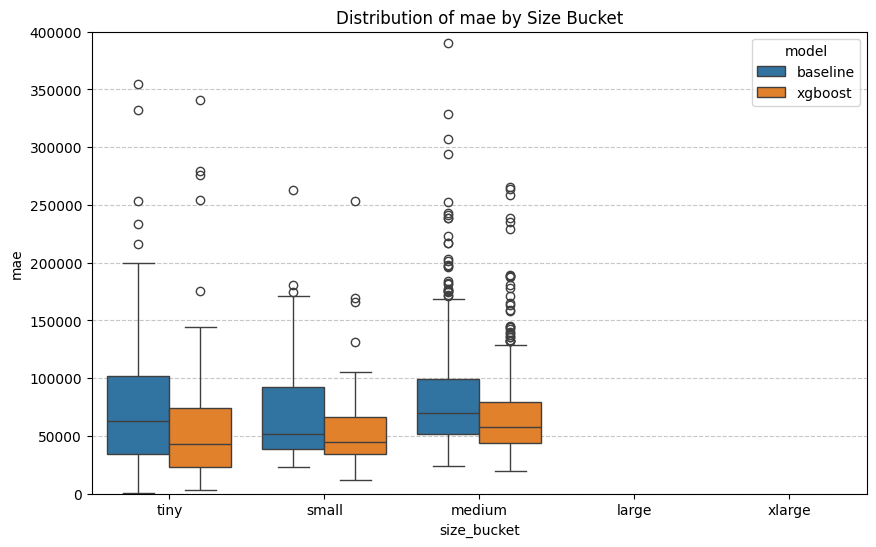

In [427]:
df = pd.read_csv('../../results_temp/finetuning/test_v4_train_v7/results.csv')
# df = df[~df['model'].isin(['baseline'])]
# baseline = pd.read_csv('../../data/test_v4/baseline_results.csv')
# df = pd.concat([df, baseline], ignore_index=True)
plot_box(df, ylim=(0, 200))
plot_box(df, 'mae', (0, 0.4e6))

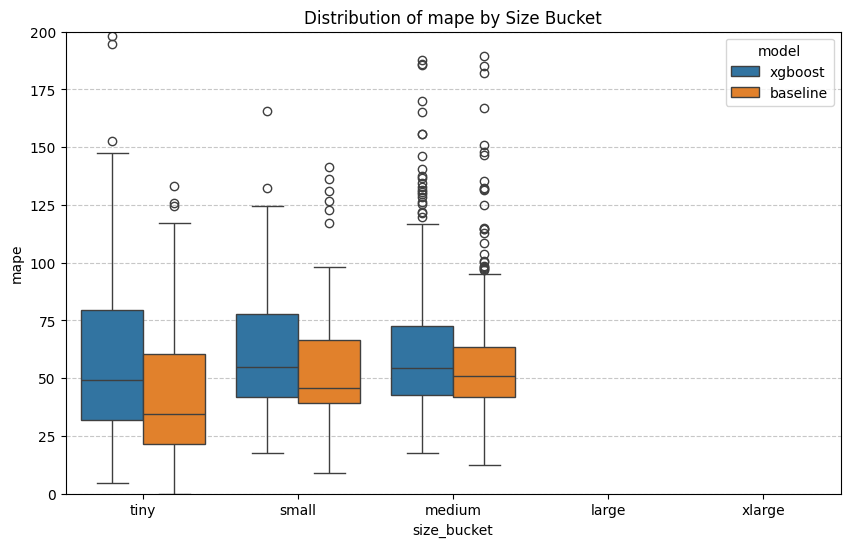

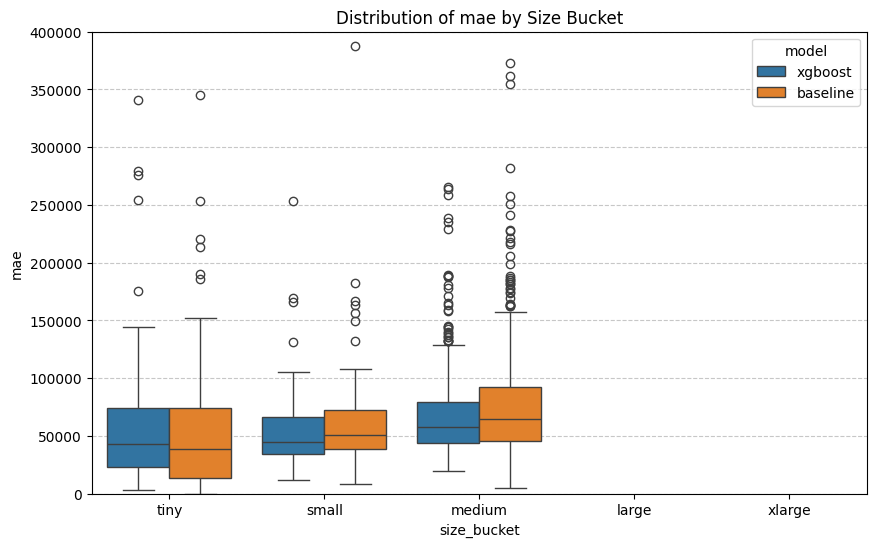

In [ ]:
df = pd.read_csv('../../results_temp/finetuning/test_v4_train_v7/results.csv')
# df = df[~df['model'].isin(['baseline'])]
# baseline = pd.read_csv('../../data/test_v4/baseline_results.csv')
# df = pd.concat([df, baseline], ignore_index=True)
plot_box(df, ylim=(0, 200))
plot_box(df, 'mae', (0, 0.4e6))

In [419]:
xgb = pd.read_parquet('../../results_temp/finetuning/test_v4_train_v7/predictions_xgboost.parquet')
# pred = pred.explode(['test_indices', 'y_true', 'y_pred']).reset_index(drop=True)
xgb = format_parquet(xgb)

baseline = pd.read_parquet('../../results_temp/finetuning/test_v4_train_v7/predictions_baseline.parquet')
baseline = format_parquet(baseline)

In [422]:
merged = xgb.merge(baseline, on='test_index', suffixes=('_xgb', '_baseline'))

In [423]:
merged

,test_index,y_true_xgb,y_pred_xgb,mae_xgb,mape_xgb,y_true_baseline,y_pred_baseline,mae_baseline,mape_baseline
0,42081,226000.0,2.052990e+05,20701.035929,0.091598,226000.0,2.927053e+05,6.670533e+04,0.295156
1,42083,70000.0,1.059255e+05,35925.451411,0.513221,70000.0,1.176493e+05,4.764934e+04,0.680705
2,42086,175000.0,1.452052e+05,29794.776033,0.170256,175000.0,1.622062e+05,1.279381e+04,0.073107
3,42087,550000.0,2.349611e+05,315038.934134,0.572798,550000.0,3.401024e+05,2.098976e+05,0.381632
4,42089,258569.0,5.070493e+04,207864.072138,0.803902,258569.0,9.552446e+03,2.490166e+05,0.963056
...,...,...,...,...,...,...,...,...,...
25276,124032,635000.0,7.205727e+05,85572.671419,0.134760,635000.0,7.073904e+05,7.239045e+04,0.114001
25277,124035,960000.0,1.070319e+06,110319.408229,0.114916,960000.0,1.346527e+06,3.865269e+05,0.402632
25278,124043,910000.0,1.027317e+06,117316.512049,0.128919,910000.0,1.130160e+06,2.201605e+05,0.241935
25279,124047,1300000.0,1.082320e+06,217680.392437,0.167446,1300000.0,2.674897e+06,1.374897e+06,1.057613


In [424]:
test1 = merged[(merged['mae_xgb'] > merged['mae_baseline']) & (merged['mape_xgb'] < merged['mape_baseline'])]
test1

,test_index,y_true_xgb,y_pred_xgb,mae_xgb,mape_xgb,y_true_baseline,y_pred_baseline,mae_baseline,mape_baseline


In [426]:
test2 = merged[(merged['mae_xgb'] < merged['mae_baseline']) & (merged['mape_xgb'] > merged['mape_baseline'])]
test2

,test_index,y_true_xgb,y_pred_xgb,mae_xgb,mape_xgb,y_true_baseline,y_pred_baseline,mae_baseline,mape_baseline


In [ ]:
# merge for FIPS

test_indices = np.load('../../data/test_v1/test_indices.npy')
train_pool_indices = np.load('../../data/test_v1/train_pool_indices.npy')
train_indices = np.load('../../data/test_v1/train_v6/train_indices.npy')

# Reconstruct the unique_indices array (sorted, deduplicated)
unique_indices = np.unique(np.concatenate([
    test_indices,
    train_pool_indices,
    train_indices
]))

# test_v5_train_v7

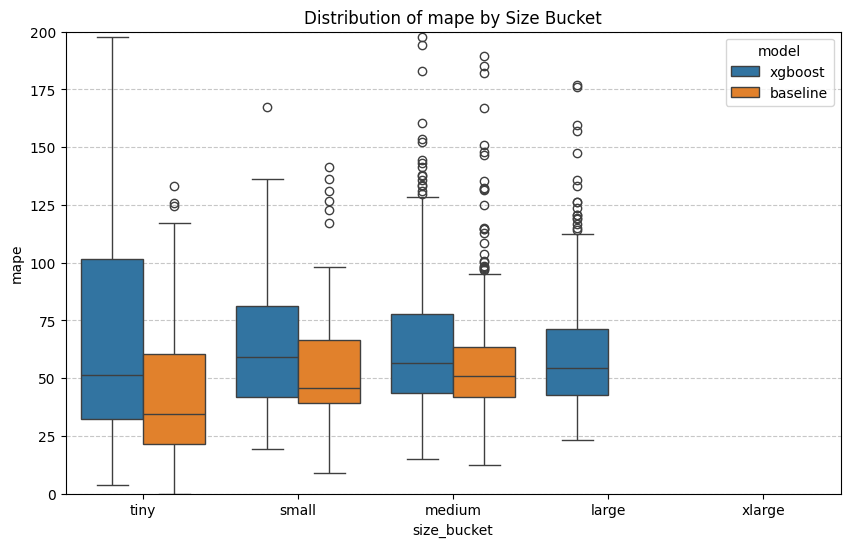

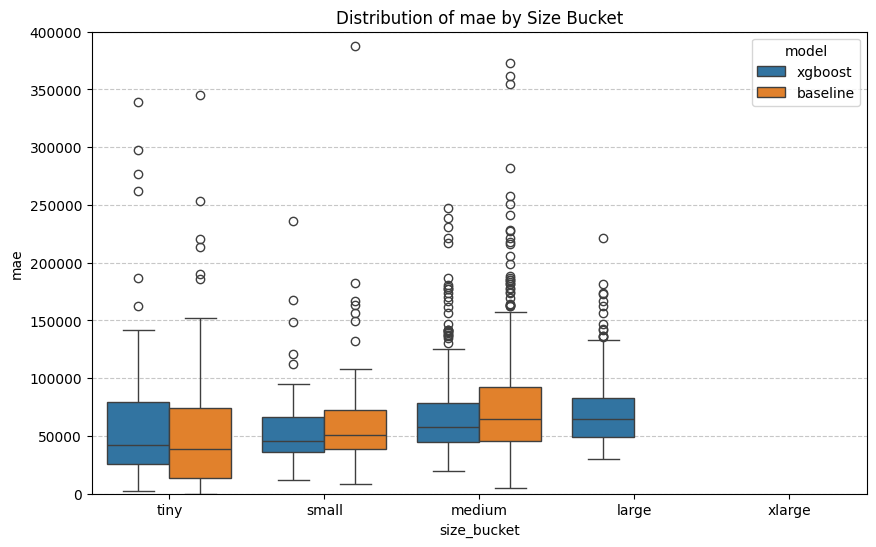

In [405]:
df = pd.read_csv('../../results_temp/finetuning/test_v5_train_v7/results.csv')
df = df[~df['model'].isin(['baseline'])]
baseline = pd.read_csv('../../data/test_v5/baseline_results.csv')
df = pd.concat([df, baseline], ignore_index=True)
plot_box(df, ylim=(0, 200))
plot_box(df, 'mae', (0, 0.4e6))

In [394]:
baseline['size_bucket'].value_counts()

size_bucket
medium    406
tiny       70
small      49
Name: count, dtype: int64

In [397]:
df[df['model'] == 'baseline']['size_bucket'].value_counts()

size_bucket
medium    812
large     406
tiny      140
small      98
xlarge      0
Name: count, dtype: int64

# try out fips proximity

In [37]:
latlon = pd.read_csv('../../data/us_county_latlng.csv')

In [50]:
latlon

,fips_code,name,lng,lat
0,1059,Franklin,-87.843283,34.442381
1,13111,Fannin,-84.319296,34.864126
2,19109,Kossuth,-94.206898,43.204140
3,40115,Ottawa,-94.810589,36.835878
4,42115,Susquehanna,-75.800905,41.821277
...,...,...,...,...
3228,12029,Dixie,-83.158705,29.608068
3229,18017,Cass,-86.346207,40.761660
3230,26091,Lenawee,-84.066412,41.894694
3231,72003,Aguada,-67.175247,18.360392


In [40]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
counties = gpd.read_file("../../data/cb_2020_us_county_500k/cb_2020_us_county_500k.shp")

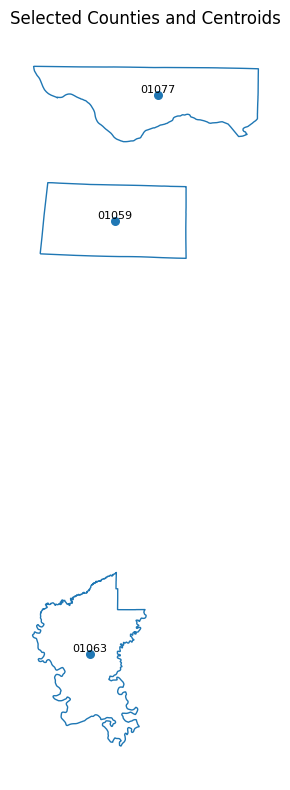

In [51]:
# --- Paths (edit these) ---
COUNTY_SHP_PATH = "../../data/cb_2020_us_county_500k/cb_2020_us_county_500k.shp"
CENTROIDS_CSV   = "../../data/us_county_latlng.csv"

# FIPS you want to plot
fips_list = ["01059", "01063", "01077"]   # example

# --- Load data ---

# Counties shapefile (Census uses GEOID for 5-digit county FIPS)
counties = gpd.read_file(COUNTY_SHP_PATH)
counties["GEOID"] = counties["GEOID"].astype(str).str.zfill(5)

# Centroids
centroids = pd.read_csv(CENTROIDS_CSV)
centroids.rename(columns={'fips_code': 'fips'}, inplace=True)
centroids["fips"] = centroids["fips"].astype(str).str.zfill(5)

# Filter to your FIPS
counties_sub  = counties[counties["GEOID"].isin(fips_list)].copy()
centroids_sub = centroids[centroids["fips"].isin(fips_list)].copy()

# Turn centroids into a GeoDataFrame
gdf_centroids = gpd.GeoDataFrame(
    centroids_sub,
    geometry=gpd.points_from_xy(centroids_sub["lng"], centroids_sub["lat"]),
    crs="EPSG:4326"
)

# Ensure both are in same CRS (just in case)
counties_sub = counties_sub.to_crs("EPSG:4326")

# --- Plot ---

fig, ax = plt.subplots(figsize=(8, 8))

# County boundaries
counties_sub.boundary.plot(ax=ax, linewidth=1)

# Centroid points
gdf_centroids.plot(ax=ax, markersize=30)

# Label with FIPS (optional)
for x, y, fips in zip(gdf_centroids.geometry.x,
                      gdf_centroids.geometry.y,
                      gdf_centroids["fips"]):
    ax.text(x, y, fips, fontsize=8, ha="center", va="bottom")

ax.set_title("Selected Counties and Centroids")
ax.set_axis_off()
plt.tight_layout()

Seems like the centroids are indeed in the middle!

In [64]:
import numpy as np
import pandas as pd

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in km
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = (np.sin(dlat/2)**2
         + np.cos(np.radians(lat1))
         * np.cos(np.radians(lat2))
         * np.sin(dlon/2)**2)
    return 2 * R * np.arcsin(np.sqrt(a))

def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8  # Earth radius in miles
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = (np.sin(dlat/2)**2
         + np.cos(np.radians(lat1))
         * np.cos(np.radians(lat2))
         * np.sin(dlon/2)**2)
    return 2 * R * np.arcsin(np.sqrt(a))

def proximity_list(fips, centroids_df, max_k=None, max_dist_miles=None):
    """
    Compute proximity list for one FIPS:
    - Sorts all other counties by centroid distance.
    - Optionally keep only the first max_k neighbors or only those within max_dist_km.
    """
    c = centroids_df[centroids_df["fips"] == fips].iloc[0]
    lat0, lon0 = c["lat"], c["lng"]

    others = centroids_df[centroids_df["fips"] != fips].copy()
    others["distance_miles"] = haversine_miles(lat0, lon0,
                                      others["lat"], others["lng"])
    others = others.sort_values("distance_miles")

    if max_k is not None:
        others = others.head(max_k)
    if max_dist_miles is not None:
        others = others[others["distance_miles"] <= max_dist_miles]

    return others[["fips", "distance_miles"]]

In [65]:
# This returns the 10 closest counties to Franklin County, AL.
proximity_list("01059", centroids, max_k=10)

,fips,distance_miles
1486,01033,17.993714
2983,01093,21.255441
2696,28141,30.508139
1209,01079,30.821987
618,28057,31.611405
3147,01077,33.494128
722,01133,33.594565
50,28117,40.375541
498,01075,48.075328
246,28081,48.898896


In [66]:
# This yields a set of counties whose centroids are < 75 km away from Franklin County, AL.
proximity_list("01059", centroids, max_dist_miles=75)


,fips,distance_miles
1486,01033,17.993714
2983,01093,21.255441
2696,28141,30.508139
1209,01079,30.821987
618,28057,31.611405
3147,01077,33.494128
722,01133,33.594565
50,28117,40.375541
498,01075,48.075328
246,28081,48.898896


# geo pooling

In [7]:
c1 = pd.read_csv('/nlp/scr/salilg/property_tax/results/geo_pooling/test_v4_geo_all/chunk_0/results.csv')
c2 = pd.read_csv('/nlp/scr/salilg/property_tax/results/geo_pooling/test_v4_geo_all/chunk_1/results.csv')
c3 = pd.read_csv('/nlp/scr/salilg/property_tax/results/geo_pooling/test_v4_geo_all/chunk_2/results.csv')
c4 = pd.read_csv('/nlp/scr/salilg/property_tax/results/geo_pooling/test_v4_geo_all/chunk_3/results.csv')
df = pd.concat([c1, c2, c3, c4], ignore_index=True)
df = df[df['status'] == 'success']

In [15]:
df.iloc[:20]

,fips,size_bucket,model,own_train_size,neighbor_train_size,total_train_size,test_size,n_features,fit_time,pred_time,r2,mae,rmse,mape,mse,status,experiment_name,experiment_description
0,1011,small,tabpfn,68,54,122,18,107,6.373325,1.180913,0.921243,35516.650002,47500.303288,64.760111,2.256279e+09,success,test_v4_geo_all,"Per-county geo pooling on all counties, neighb..."
1,1011,small,xgboost,68,54,122,18,107,64.225823,0.013025,0.951891,27876.420130,37124.819027,75.888929,1.378252e+09,success,test_v4_geo_all,"Per-county geo pooling on all counties, neighb..."
2,1013,medium,tabpfn,396,316,712,101,107,1.016364,0.500338,0.519981,37253.688786,65493.605071,79.503505,4.289412e+09,success,test_v4_geo_all,"Per-county geo pooling on all counties, neighb..."
3,1013,medium,xgboost,396,316,712,101,107,67.889488,0.011979,0.690541,34187.402856,52586.123196,66.554110,2.765300e+09,success,test_v4_geo_all,"Per-county geo pooling on all counties, neighb..."
4,1025,medium,tabpfn,234,187,421,65,107,0.901485,1.708202,0.612986,31598.206010,44084.372648,62.865933,1.943432e+09,success,test_v4_geo_all,"Per-county geo pooling on all counties, neighb..."
5,1025,medium,xgboost,234,187,421,65,107,106.033895,0.019752,0.445103,38830.951142,52787.037864,81.411939,2.786471e+09,success,test_v4_geo_all,"Per-county geo pooling on all counties, neighb..."
6,1029,medium,tabpfn,224,179,403,57,107,0.875984,2.042287,0.081446,77423.252501,109247.694882,48.381835,1.193506e+10,success,test_v4_geo_all,"Per-county geo pooling on all counties, neighb..."
7,1029,medium,xgboost,224,179,403,57,107,72.443966,0.011739,0.237031,71461.555030,99566.476179,50.421056,9.913483e+09,success,test_v4_geo_all,"Per-county geo pooling on all counties, neighb..."
8,1037,medium,tabpfn,360,288,648,92,107,1.422962,0.514963,0.422824,101238.392992,188565.972534,59.143400,3.555713e+10,success,test_v4_geo_all,"Per-county geo pooling on all counties, neighb..."
9,1037,medium,xgboost,360,288,648,92,107,68.385273,0.013620,0.443093,99557.035804,185225.357717,63.893954,3.430843e+10,success,test_v4_geo_all,"Per-county geo pooling on all counties, neighb..."


In [ ]:
def plot_line_with_se(df, column='mape', ylim=None):
    # 1. Ensure logical order of size buckets
    category_order = ['tiny', 'small', 'medium']  # extend if needed
    df = df.copy()
    df['size_bucket'] = pd.Categorical(
        df['size_bucket'], categories=category_order, ordered=True
    )

    # 2. Aggregate: mean + standard error per (size_bucket, model)
    stats = (
        df
        .groupby(['size_bucket', 'model'])[column]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    stats['se'] = stats['std'] / np.sqrt(stats['count'])

    # Map size_bucket to x positions
    cat_to_x = {cat: i for i, cat in enumerate(category_order)}
    stats['x'] = stats['size_bucket'].map(cat_to_x)

    # 3. Plot
    plt.figure(figsize=(10, 6))
    ax = plt.gca()

    # One line per model
    for model, mdf in stats.groupby('model'):
        mdf = mdf.sort_values('x')
        ax.errorbar(
            mdf['x'],
            mdf['mean'],
            yerr=mdf['se'],      # mean ± 1 SE; change to 2*mdf['se'] for ~95% CI
            fmt='-o',
            capsize=4,
            linewidth=2,
            label=model,
        )

    # 4. Axis formatting
    ax.set_xticks(range(len(category_order)))
    ax.set_xticklabels(category_order)
    ax.set_xlabel('size_bucket')
    ax.set_ylabel(column)
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_title(f'Distribution of {column} by Size Bucket (mean ± SE)')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend(title='model')

    plt.tight_layout()
    plt.show()

/tmp/user/24606/ipykernel_1722522/2381568460.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['size_bucket', 'model'])[column]


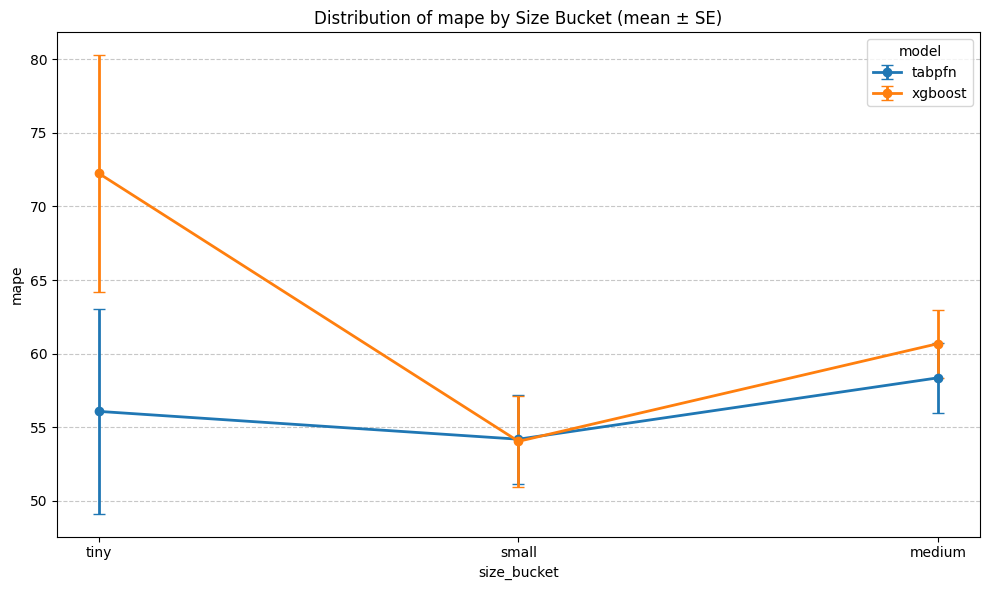

In [16]:
plot_line_with_se(df, 'mape')

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_line_by_train_size(df,
                            metric='mape',
                            train_size_col='own_train_size',
                            ylim=None,
                            bucket_size=None):
    """
    Plot mean ± SE of `metric` for each model as a function of training size.

    Parameters
    ----------
    df : DataFrame
    metric : str
        Column name of the metric (e.g., 'mape', 'mae').
    train_size_col : str
        Column name with training size (numeric).
    ylim : tuple or None
        If set, passed to plt.ylim.
    bucket_size : int or None
        If None: no binning, one point per distinct train_size.
        If int: bin train_size into [0,bucket_size), [bucket_size,2*bucket_size), ...
                and aggregate within each bin.
    """
    df = df.copy()

    # Decide on x-variable: raw train size or bucketed size
    if bucket_size is not None:
        # bucket_start = 0,20,40,... for bucket_size=20, etc.
        bucket_col = '_train_bucket_start'
        df[bucket_col] = (df[train_size_col] // bucket_size) * bucket_size
        x_col = bucket_col
    else:
        x_col = train_size_col

    # Aggregate: mean, std, count per (x, model)
    stats = (
        df
        .groupby([x_col, 'model'])[metric]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    stats['se'] = stats['std'] / np.sqrt(stats['count'])

    plt.figure(figsize=(10, 6))
    ax = plt.gca()

    # Plot one line per model
    for model, mdf in stats.groupby('model'):
        mdf = mdf.sort_values(x_col)

        ax.errorbar(
            mdf[x_col],
            mdf['mean'],
            yerr=mdf['se'],        # change to 2*mdf['se'] for ±2 SE
            fmt='-o',
            capsize=4,
            linewidth=2,
            label=model
        )

    # Axis labels & ticks
    if bucket_size is not None:
        # x values are bucket starts; label as ranges like "0–20", "20–40", ...
        xs = sorted(stats[x_col].unique())
        ax.set_xticks(xs)
        ax.set_xticklabels([f'{x}–{x+bucket_size}' for x in xs])
        ax.set_xlabel(f'{train_size_col} (binned, width={bucket_size})')
    else:
        ax.set_xlabel(train_size_col)

    ax.set_ylabel(metric)
    if ylim is not None:
        ax.set_ylim(ylim)

    title_suffix = f' (bucket size = {bucket_size})' if bucket_size is not None else ''
    ax.set_title(f'Mean ± SE of {metric} by Training Size{title_suffix}')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend(title='model')

    plt.tight_layout()
    plt.show()

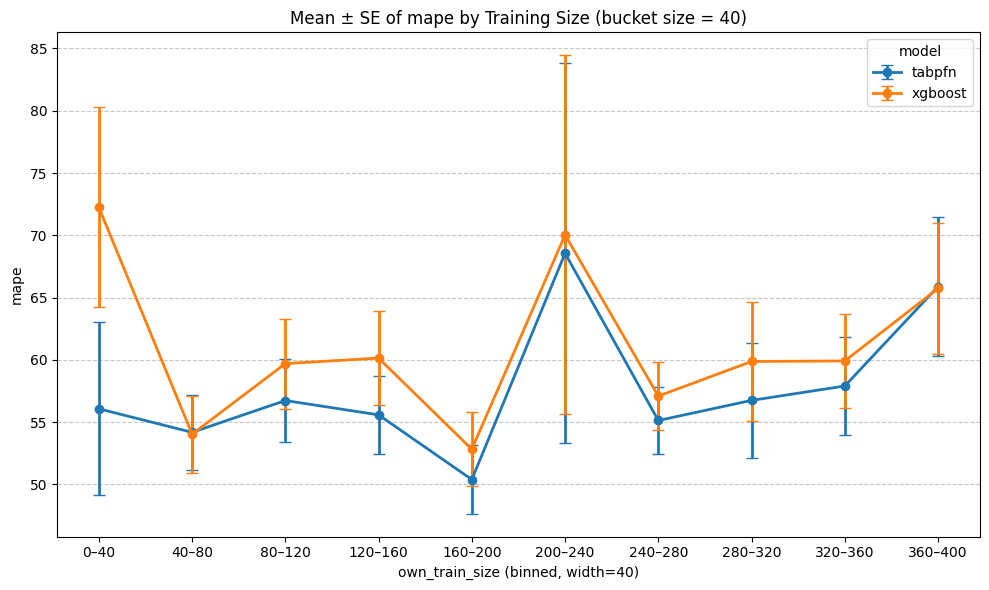

In [ ]:

plot_line_by_train_size(df[~df['fips'].isin(['53055'])], bucket_size=40)

In [42]:
df2 = df[~df['fips'].isin(['53055'])]
df2[df2['model'] == 'tabpfn']['mape'].describe()

count    517.000000
mean      57.686635
std       46.921268
min       11.029348
25%       40.244942
50%       49.692151
75%       64.734097
max      866.524215
Name: mape, dtype: float64

In [43]:
df2[(df2['own_train_size'] > 200) & (df2['own_train_size'] < 240)].describe()

,fips,own_train_size,neighbor_train_size,total_train_size,test_size,n_features,fit_time,pred_time,r2,mae,rmse,mape,mse
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.0,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,1.060000e+02
mean,34170.867925,219.679245,175.339623,395.018868,55.792453,107.0,42.376680,0.973841,0.313783,77069.264701,110272.109964,69.842974,2.560662e+10
std,15917.958890,10.307230,8.280657,18.585699,3.069720,0.0,43.068693,1.045103,0.308266,84409.530393,116510.712581,109.474070,9.839397e+10
min,1025.000000,202.000000,161.000000,363.000000,51.000000,107.0,0.785678,0.010794,-0.846945,22772.412949,35317.228779,27.050365,1.247307e+09
25%,21109.000000,212.000000,169.000000,381.000000,54.000000,107.0,1.569045,0.015482,0.149664,45707.831203,64831.622517,42.946706,4.203141e+09
50%,38019.000000,219.000000,175.000000,394.000000,56.000000,107.0,29.853539,0.442837,0.351003,57723.159739,86691.819643,49.796448,7.515475e+09
75%,48369.000000,228.000000,182.000000,410.000000,57.000000,107.0,79.639589,1.840464,0.505717,72021.438195,104550.321040,62.199943,1.093114e+10
max,55078.000000,239.000000,191.000000,430.000000,65.000000,107.0,138.960244,3.908253,0.810223,615094.749421,872327.420830,866.524215,7.609551e+11


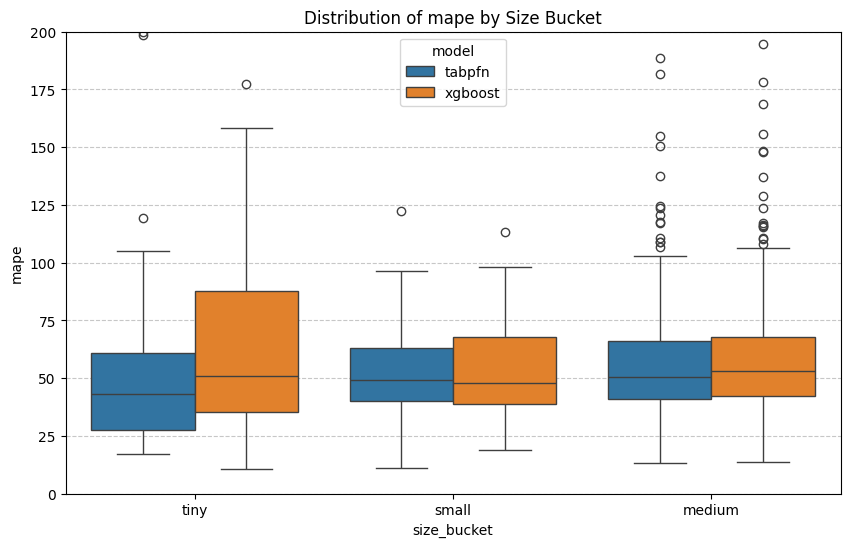

In [11]:
plot_box(df, 'mape', (0, 200))